# Survival and Competing-Risk Analysis for Clinical Research

## Clinical Melanoma Prognosis After Surgical Treatment

### Project Overview

This project develops a reproducible clinical survival-analysis workflow using publicly available follow-up data for patients who underwent surgical removal of malignant melanoma. The analysis examines how patient and tumour characteristics relate to the timing of mortality after surgery.

Unlike a standard binary-outcome analysis, survival analysis accounts for both the occurrence and timing of clinical events. It also accommodates patients whose complete event history is not observed during the available follow-up period.

A further challenge arises because mortality can occur through different pathways. A patient may die from melanoma or from an unrelated cause. These outcomes are mutually exclusive: once one occurs, the other can no longer occur. This motivates a competing-risk analysis alongside the conventional survival workflow.

---

## Clinical Research Questions

### Primary Question

Which patient and tumour characteristics are associated with the hazard of all-cause mortality after melanoma surgery?

### Competing-Risk Question

How does the cumulative incidence of melanoma-specific death differ from death due to other causes, particularly according to tumour ulceration status?

---

## Planned Analytical Workflow

The project will include:

* clinical dataset preparation and quality checks,
* time-to-event and censoring assessment,
* Kaplan–Meier survival estimation,
* log-rank comparison of survival distributions,
* multivariable Cox proportional-hazards modeling,
* proportional-hazards diagnostics,
* interpretable hazard-ratio summaries,
* adjusted survival curves,
* cause-specific competing-risk analysis,
* cumulative-incidence estimation,
* sensitivity and robustness checks,
* publication-style figures and tables,
* and cautious clinical interpretation.

---

## Interpretation Boundary

This is an observational prognostic analysis. The estimated associations should not be interpreted as causal effects of tumour characteristics or patient factors. Kaplan–Meier curves, Cox models, and competing-risk methods answer related but distinct questions. Their findings will therefore be interpreted carefully, with explicit attention to censoring, model assumptions, and the distinction between all-cause mortality, cause-specific hazards, and cumulative incidence.


---

## 1. Environment Setup and Reproducibility

This section prepares the Python environment for a reproducible clinical survival-analysis workflow. The analysis will use established scientific-computing libraries for data management, statistical modeling, survival estimation, competing-risk analysis, and publication-style visualization.

The required packages will be installed explicitly so that the notebook can be executed consistently in a fresh Google Colab session. A fixed visual theme and random seed will also be defined later where appropriate to improve reproducibility.

### Main Analytical Libraries

* **pandas** and **NumPy** for structured data preparation,
* **Matplotlib** and **Seaborn** for publication-style figures,
* **lifelines** for Kaplan–Meier estimation, log-rank testing, Cox proportional-hazards modeling, diagnostics, adjusted survival curves, and cumulative-incidence estimation,
* **statsmodels** for access to the publicly available clinical dataset and supporting statistical utilities.


In [1]:
# Install the specialized survival-analysis library
%pip -q install lifelines==0.30.3

In [2]:
# Core scientific-computing libraries
import sys
import platform
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Survival-analysis tools
from lifelines import KaplanMeierFitter, CoxPHFitter, AalenJohansenFitter
from lifelines.statistics import logrank_test

# Reproducibility and clean notebook display
np.random.seed(42)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Record the computational environment
print("Environment successfully configured.")
print(f"Python:       {sys.version.split()[0]}")
print(f"Platform:     {platform.system()}")
print(f"NumPy:        {np.__version__}")
print(f"pandas:       {pd.__version__}")
print(f"Matplotlib:   {version('matplotlib')}")
print(f"statsmodels:  {version('statsmodels')}")
print(f"lifelines:    {version('lifelines')}")

Environment successfully configured.
Python:       3.12.13
Platform:     Linux
NumPy:        2.0.2
pandas:       2.2.2
Matplotlib:   3.10.0
statsmodels:  0.14.6
lifelines:    0.30.3


---

## 2. Clinical Dataset Acquisition

### Public Clinical Data Source

This project uses the publicly available **melanoma** dataset from the R `boot` package. The dataset contains follow-up information for patients who underwent surgical removal of malignant melanoma. It provides a compact but clinically meaningful setting for demonstrating both conventional survival analysis and competing-risk methods.

The available variables include:

* survival time in days following surgery,
* final follow-up status,
* patient sex,
* age at the time of surgery,
* year of surgery,
* tumour thickness in millimetres,
* and tumour ulceration status.

### Outcome Framework

The original status variable distinguishes three mutually exclusive outcomes:

* `status = 1`: death from melanoma,
* `status = 2`: alive at the end of follow-up,
* `status = 3`: death from a cause unrelated to melanoma.

For the conventional survival analysis, deaths from any cause will initially be treated as events. For the competing-risk analysis, melanoma-related death and death from other causes will be evaluated as distinct outcomes.

### Data-Preparation Principle

The original dataset will be preserved as a raw dataframe. Transparent analysis variables will then be created separately so that the operational definitions of censoring, all-cause mortality, melanoma-specific death, and competing death remain explicit and reproducible.

Before fitting any models, the dataset structure, variable types, sample size, missingness, and outcome frequencies will be inspected carefully.


In [3]:
# Load the publicly available melanoma clinical survival dataset
melanoma_raw = sm.datasets.get_rdataset(
    dataname="melanoma",
    package="boot",
    cache=True
).data.copy()

# Inspect the raw dataset without modifying it
print("Raw melanoma dataset loaded successfully.")
print(f"Number of patients: {melanoma_raw.shape[0]}")
print(f"Number of original variables: {melanoma_raw.shape[1]}")

print("\nOriginal column names:")
print(list(melanoma_raw.columns))

print("\nFirst five rows:")
display(melanoma_raw.head())

Raw melanoma dataset loaded successfully.
Number of patients: 205
Number of original variables: 7

Original column names:
['time', 'status', 'sex', 'age', 'year', 'thickness', 'ulcer']

First five rows:


,time,status,sex,age,year,thickness,ulcer
0,10,3,1,76,1972,6.760,1
1,30,3,1,56,1968,0.650,0
2,35,2,1,41,1977,1.340,0
3,99,3,0,71,1968,2.900,0
4,185,1,1,52,1965,12.080,1


---

## 3. Data Structure and Clinical Quality Audit

Before defining analytical outcomes or fitting survival models, the raw dataset must be examined carefully. This stage verifies the integrity of the clinical follow-up information and identifies any data-quality concerns that could affect interpretation.

The audit will assess:

* dataframe dimensions and variable types,
* duplicated patient records,
* missing values,
* implausible or non-positive follow-up times,
* frequencies of the original outcome categories,
* distributions of continuous clinical variables,
* and category frequencies for sex and tumour ulceration status.

Particular attention will be given to the original `status` variable because it determines how events and censoring are defined later. The raw outcome coding will remain unchanged, while new analysis variables will be created transparently in a separate dataframe.

This separation protects the original data and makes the analytical decisions reproducible.


In [4]:
# Raw-data quality audit: inspect the original dataset without modifying it

expected_categories = {
    "status": {1, 2, 3},
    "sex": {0, 1},
    "ulcer": {0, 1},
}

audit_summary = pd.DataFrame(
    {
        "check": [
            "Number of patients",
            "Number of original variables",
            "Duplicated rows",
            "Total missing values",
            "Non-positive follow-up times",
            "Negative ages",
            "Non-positive tumour thickness values",
            "Unexpected status codes",
            "Unexpected sex codes",
            "Unexpected ulceration codes",
        ],
        "result": [
            melanoma_raw.shape[0],
            melanoma_raw.shape[1],
            int(melanoma_raw.duplicated().sum()),
            int(melanoma_raw.isna().sum().sum()),
            int((melanoma_raw["time"] <= 0).sum()),
            int((melanoma_raw["age"] < 0).sum()),
            int((melanoma_raw["thickness"] <= 0).sum()),
            sorted(set(melanoma_raw["status"].dropna()) - expected_categories["status"]),
            sorted(set(melanoma_raw["sex"].dropna()) - expected_categories["sex"]),
            sorted(set(melanoma_raw["ulcer"].dropna()) - expected_categories["ulcer"]),
        ],
    }
)

print("RAW DATA QUALITY AUDIT")
display(audit_summary)

print("\nMISSING VALUES BY VARIABLE")
display(
    melanoma_raw.isna()
    .sum()
    .rename("missing_n")
    .to_frame()
)

print("\nORIGINAL STATUS FREQUENCIES")
display(
    melanoma_raw["status"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("status")
    .reset_index(name="patients_n")
)

print("\nSEX FREQUENCIES")
display(
    melanoma_raw["sex"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("sex")
    .reset_index(name="patients_n")
)

print("\nULCERATION FREQUENCIES")
display(
    melanoma_raw["ulcer"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("ulcer")
    .reset_index(name="patients_n")
)

print("\nCONTINUOUS-VARIABLE SUMMARY")
display(
    melanoma_raw[["time", "age", "year", "thickness"]]
    .describe()
    .T
)

RAW DATA QUALITY AUDIT


,check,result
0,Number of patients,205
1,Number of original variables,7
2,Duplicated rows,0
3,Total missing values,0
4,Non-positive follow-up times,0
5,Negative ages,0
6,Non-positive tumour thickness values,0
7,Unexpected status codes,[]
8,Unexpected sex codes,[]
9,Unexpected ulceration codes,[]



MISSING VALUES BY VARIABLE


,missing_n
time,0
status,0
sex,0
age,0
year,0
thickness,0
ulcer,0



ORIGINAL STATUS FREQUENCIES


...

,sex,patients_n
0,0,126
1,1,79



ULCERATION FREQUENCIES


,ulcer,patients_n
0,0,115
1,1,90



CONTINUOUS-VARIABLE SUMMARY


,count,mean,std,min,25%,50%,75%,max
time,205.000,"2,152.800","1,122.061",10.000,"1,525.000","2,005.000","3,042.000","5,565.000"
age,205.000,52.463,16.672,4.000,42.000,54.000,65.000,95.000
year,205.000,"1,969.907",2.576,"1,962.000","1,968.000","1,970.000","1,972.000","1,977.000"
thickness,205.000,2.920,2.959,0.100,0.970,1.940,3.560,17.420


---

## 4. Analytical Outcome Definitions

The original clinical dataset records three mutually exclusive follow-up outcomes. To support several complementary survival-analysis methods, transparent derived variables will be created in a separate analysis dataframe while preserving the raw data unchanged.

### Follow-Up Time

The original follow-up duration is recorded in days. A corresponding variable in years will also be created to make the clinical interpretation of survival curves and model outputs more intuitive.

### Conventional All-Cause Survival Outcome

For the primary survival workflow:

* `all_cause_event = 1` for death from any cause,
* `all_cause_event = 0` for patients alive at the end of follow-up.

This outcome will be used for Kaplan–Meier estimation, the log-rank comparison, and the primary Cox proportional-hazards model.

### Competing-Risk Outcome

For competing-risk analysis:

* `competing_event = 0` for patients alive at the end of follow-up,
* `competing_event = 1` for melanoma-related death,
* `competing_event = 2` for death from another cause.

This coding recognizes that melanoma-related death and death from other causes are mutually exclusive outcomes. A patient who experiences one type of death can no longer experience the other.

### Clinical Group Labels

Readable labels will also be created for:

* patient sex,
* tumour ulceration status,
* and the original follow-up outcome.

These labels will make the summary tables and publication-style figures easier to interpret.

### Interpretation Principle

The conventional all-cause survival analysis and the competing-risk analysis answer different questions. The first evaluates the timing of mortality from any cause. The second separates the probability of melanoma-related death from the probability of death due to other causes while respecting their competing nature.


In [5]:
# Create a separate analysis dataframe while preserving the raw dataset
melanoma = melanoma_raw.copy()

# Convert follow-up time from days to years for clinically intuitive interpretation
melanoma["time_years"] = melanoma["time"] / 365.25

# Define conventional all-cause mortality outcome:
# 1 = death from any cause, 0 = alive at the end of follow-up
melanoma["all_cause_event"] = melanoma["status"].isin([1, 3]).astype(int)

# Define competing-risk outcome:
# 0 = alive/censored, 1 = melanoma-related death, 2 = death from another cause
melanoma["competing_event"] = melanoma["status"].map(
    {
        1: 1,
        2: 0,
        3: 2,
    }
).astype(int)

# Create readable clinical labels
melanoma["sex_label"] = melanoma["sex"].map(
    {
        0: "Female",
        1: "Male",
    }
)

melanoma["ulcer_label"] = melanoma["ulcer"].map(
    {
        0: "Absent",
        1: "Present",
    }
)

melanoma["outcome_label"] = melanoma["status"].map(
    {
        1: "Death from melanoma",
        2: "Alive at end of follow-up",
        3: "Death from other causes",
    }
)

melanoma["competing_event_label"] = melanoma["competing_event"].map(
    {
        0: "Alive / censored",
        1: "Death from melanoma",
        2: "Death from other causes",
    }
)

# Verify that the derived outcomes were created correctly
assert melanoma["all_cause_event"].isin([0, 1]).all()
assert melanoma["competing_event"].isin([0, 1, 2]).all()
assert melanoma["time_years"].gt(0).all()

print("Analysis variables created successfully.")
print(f"Patients retained: {melanoma.shape[0]}")

print("\nFIRST FIVE ROWS OF THE ANALYSIS DATAFRAME")
display(
    melanoma[
        [
            "time",
            "time_years",
            "status",
            "outcome_label",
            "all_cause_event",
            "competing_event",
            "sex_label",
            "age",
            "thickness",
            "ulcer_label",
        ]
    ].head()
)

print("\nALL-CAUSE SURVIVAL OUTCOME FREQUENCIES")
display(
    melanoma["all_cause_event"]
    .value_counts()
    .sort_index()
    .rename_axis("all_cause_event")
    .reset_index(name="patients_n")
)

print("\nCOMPETING-RISK OUTCOME FREQUENCIES")
display(
    melanoma["competing_event_label"]
    .value_counts()
    .rename_axis("outcome")
    .reset_index(name="patients_n")
)

Analysis variables created successfully.
Patients retained: 205

FIRST FIVE ROWS OF THE ANALYSIS DATAFRAME


,time,time_years,status,outcome_label,all_cause_event,competing_event,sex_label,age,thickness,ulcer_label
0,10,0.027,3,Death from other causes,1,2,Male,76,6.760,Present
1,30,0.082,3,Death from other causes,1,2,Male,56,0.650,Absent
2,35,0.096,2,Alive at end of follow-up,0,0,Male,41,1.340,Absent
3,99,0.271,3,Death from other causes,1,2,Female,71,2.900,Absent
4,185,0.507,1,Death from melanoma,1,1,Male,52,12.080,Present



ALL-CAUSE SURVIVAL OUTCOME FREQUENCIES


,all_cause_event,patients_n
0,0,134
1,1,71



COMPETING-RISK OUTCOME FREQUENCIES


,outcome,patients_n
0,Alive / censored,134
1,Death from melanoma,57
2,Death from other causes,14


---

## 5. Clinical Cohort Profile and Censoring Assessment

Before estimating survival curves, the clinical cohort and available follow-up information must be summarized clearly. This provides context for interpreting subsequent model estimates and helps identify whether the observed number of events is sufficient for a focused multivariable analysis.

### Cohort Description

A publication-style baseline table will summarize:

* sample size,
* patient age,
* sex,
* year of surgery,
* tumour thickness,
* ulceration status,
* follow-up duration,
* all-cause mortality,
* melanoma-related death,
* death from other causes,
* and censoring status.

The characteristics will be reported for the full cohort and stratified by tumour ulceration status because ulceration is a clinically meaningful prognostic feature and will be used for the initial Kaplan–Meier comparison.

### Censoring Assessment

In survival analysis, a censored patient is not assumed to be permanently event-free. Censoring means only that the event was not observed during the available follow-up period.

The analysis will therefore report:

* the number and percentage of censored observations,
* the number and percentage of observed deaths,
* the range and distribution of observed follow-up time,
* and the median potential follow-up estimated using the reverse Kaplan–Meier method.

The reverse Kaplan–Meier method treats censoring times as the events of interest when summarizing follow-up availability. This provides a more appropriate estimate of potential follow-up duration than a simple median of the observed times alone.

### Modeling Principle

The number of observed deaths, rather than the total sample size alone, limits the complexity of the Cox proportional-hazards model. The adjusted model will therefore remain focused and parsimonious to avoid unstable estimates and overfitting.


In [6]:
# Create the repository-ready outputs folder at the analytical stage
from pathlib import Path

outputs_dir = Path("outputs")
outputs_dir.mkdir(exist_ok=True)

# Reverse Kaplan–Meier estimation:
# censoring observations are treated as events,
# while observed deaths are treated as censored observations
reverse_km = KaplanMeierFitter()

reverse_km.fit(
    durations=melanoma["time_years"],
    event_observed=1 - melanoma["all_cause_event"],
    label="Potential follow-up"
)

median_potential_followup = reverse_km.median_survival_time_

# Create a concise censoring and follow-up summary
censoring_summary = pd.DataFrame(
    {
        "metric": [
            "Total patients",
            "Observed all-cause deaths",
            "Observed all-cause deaths (%)",
            "Censored patients",
            "Censored patients (%)",
            "Minimum observed follow-up (years)",
            "Median observed follow-up (years)",
            "Maximum observed follow-up (years)",
            "Median potential follow-up: reverse Kaplan–Meier (years)",
        ],
        "value": [
            len(melanoma),
            int(melanoma["all_cause_event"].sum()),
            100 * melanoma["all_cause_event"].mean(),
            int((1 - melanoma["all_cause_event"]).sum()),
            100 * (1 - melanoma["all_cause_event"]).mean(),
            melanoma["time_years"].min(),
            melanoma["time_years"].median(),
            melanoma["time_years"].max(),
            median_potential_followup,
        ],
    }
)

# Save a repository-ready CSV table
censoring_summary.to_csv(
    outputs_dir / "censoring_followup_summary.csv",
    index=False
)

print("CENSORING AND FOLLOW-UP SUMMARY")
display(censoring_summary)

print("\nSaved file:")
print(outputs_dir / "censoring_followup_summary.csv")

CENSORING AND FOLLOW-UP SUMMARY


,metric,value
0,Total patients,205.000
1,Observed all-cause deaths,71.000
2,Observed all-cause deaths (%),34.634
3,Censored patients,134.000
4,Censored patients (%),65.366
5,Minimum observed follow-up (years),0.027
6,Median observed follow-up (years),5.489
7,Maximum observed follow-up (years),15.236
8,Median potential follow-up: reverse Kaplan–Mei...,6.823



Saved file:
outputs/censoring_followup_summary.csv


In [7]:
# Create a publication-style cohort profile for the full sample
# and stratified by tumour ulceration status

def format_n_pct(series, condition):
    """Return count and within-group percentage as a publication-style string."""
    n = int(condition.sum())
    pct = 100 * n / len(series)
    return f"{n} ({pct:.1f}%)"


def format_mean_sd(series):
    """Return mean and standard deviation."""
    return f"{series.mean():.2f} ({series.std():.2f})"


def format_median_iqr(series):
    """Return median and interquartile range."""
    q1 = series.quantile(0.25)
    median = series.median()
    q3 = series.quantile(0.75)
    return f"{median:.2f} [{q1:.2f}, {q3:.2f}]"


def summarize_group(df):
    """Create a clinically interpretable summary for one cohort or subgroup."""
    return {
        "Patients, n": str(len(df)),
        "Age, years: mean (SD)": format_mean_sd(df["age"]),
        "Male sex, n (%)": format_n_pct(df, df["sex"] == 1),
        "Female sex, n (%)": format_n_pct(df, df["sex"] == 0),
        "Year of surgery: mean (SD)": format_mean_sd(df["year"]),
        "Tumour thickness, mm: median [IQR]": format_median_iqr(df["thickness"]),
        "Observed follow-up, years: median [IQR]": format_median_iqr(df["time_years"]),
        "All-cause deaths, n (%)": format_n_pct(df, df["all_cause_event"] == 1),
        "Melanoma-related deaths, n (%)": format_n_pct(df, df["competing_event"] == 1),
        "Deaths from other causes, n (%)": format_n_pct(df, df["competing_event"] == 2),
        "Alive / censored, n (%)": format_n_pct(df, df["competing_event"] == 0),
    }


# Build full-cohort and ulceration-stratified summaries
cohort_summary = pd.DataFrame(
    {
        "Full cohort": summarize_group(melanoma),
        "Ulceration absent": summarize_group(
            melanoma.loc[melanoma["ulcer"] == 0]
        ),
        "Ulceration present": summarize_group(
            melanoma.loc[melanoma["ulcer"] == 1]
        ),
    }
)

cohort_summary.index.name = "Characteristic"

# Save a repository-ready publication-style CSV table
cohort_summary.to_csv(
    outputs_dir / "clinical_cohort_profile_by_ulceration.csv"
)

print("CLINICAL COHORT PROFILE BY TUMOUR ULCERATION STATUS")
display(cohort_summary)

print("\nSaved file:")
print(outputs_dir / "clinical_cohort_profile_by_ulceration.csv")

CLINICAL COHORT PROFILE BY TUMOUR ULCERATION STATUS


,Full cohort,Ulceration absent,Ulceration present
Characteristic,,,
"Patients, n",205,115,90
"Age, years: mean (SD)",52.46 (16.67),50.61 (15.90),54.83 (17.41)
"Male sex, n (%)",79 (38.5%),36 (31.3%),43 (47.8%)
"Female sex, n (%)",126 (61.5%),79 (68.7%),47 (52.2%)
Year of surgery: mean (SD),1969.91 (2.58),1969.98 (2.73),1969.81 (2.38)
"Tumour thickness, mm: median [IQR]","1.94 [0.97, 3.56]","1.29 [0.65, 1.94]","3.54 [2.25, 5.16]"
"Observed follow-up, years: median [IQR]","5.49 [4.18, 8.33]","5.76 [4.60, 8.71]","4.93 [2.27, 6.81]"
"All-cause deaths, n (%)",71 (34.6%),23 (20.0%),48 (53.3%)
"Melanoma-related deaths, n (%)",57 (27.8%),16 (13.9%),41 (45.6%)



Saved file:
outputs/clinical_cohort_profile_by_ulceration.csv


---

## 6. Kaplan–Meier Survival Analysis

The Kaplan–Meier estimator will be used to describe all-cause survival after melanoma surgery. In this initial analysis, death from any cause is treated as the event of interest, while patients who remained alive at the end of their observed follow-up are treated as censored observations.

### Overall Survival Curve

An overall Kaplan–Meier curve will summarize the estimated probability of remaining alive over time for the full clinical cohort. The figure will include:

* the estimated survival function,
* a 95% confidence interval,
* censoring marks,
* and a compact risk table showing the number of patients still under observation at selected time points.

### Survival Comparison by Tumour Ulceration

Separate Kaplan–Meier curves will then compare patients with and without tumour ulceration. Tumour ulceration is a clinically relevant prognostic feature, and the descriptive cohort table suggests meaningful differences in observed mortality between the two groups.

A log-rank test will assess whether the unadjusted survival distributions differ statistically across the ulceration groups.

### Interpretation Boundary

Kaplan–Meier curves and the log-rank test provide unadjusted comparisons. Any observed difference should not be interpreted as an independent effect of tumour ulceration because the groups may differ in other prognostic characteristics, including tumour thickness, age, and sex composition. Adjusted modeling will therefore follow in a later section.


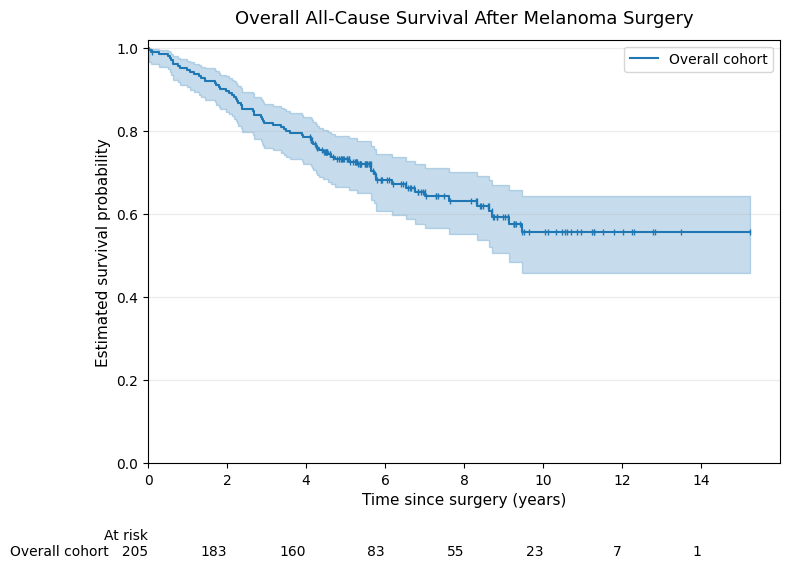

Saved figure:
outputs/km_overall_all_cause_survival.png


In [8]:
# Overall Kaplan–Meier estimate for all-cause survival
from lifelines.plotting import add_at_risk_counts

km_overall = KaplanMeierFitter(label="Overall cohort")

km_overall.fit(
    durations=melanoma["time_years"],
    event_observed=melanoma["all_cause_event"]
)

# Create a publication-style survival figure
fig, ax = plt.subplots(figsize=(8, 6))

km_overall.plot_survival_function(
    ax=ax,
    ci_show=True,
    show_censors=True,
    censor_styles={
        "marker": "|",
        "ms": 5,
        "mew": 1,
    }
)

ax.set_title(
    "Overall All-Cause Survival After Melanoma Surgery",
    fontsize=13,
    pad=12
)
ax.set_xlabel("Time since surgery (years)", fontsize=11)
ax.set_ylabel("Estimated survival probability", fontsize=11)
ax.set_xlim(left=0)
ax.set_ylim(0, 1.02)
ax.grid(axis="y", alpha=0.25)

# Add the number of patients still under observation
add_at_risk_counts(
    km_overall,
    ax=ax,
    rows_to_show=["At risk"]
)

plt.tight_layout()

# Save a repository-ready high-resolution PNG figure
figure_path = outputs_dir / "km_overall_all_cause_survival.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:")
print(figure_path)

In [9]:
# Summarize overall Kaplan–Meier survival probabilities
# at clinically interpretable follow-up times

selected_times = [1, 3, 5, 10]

overall_km_summary = pd.DataFrame(
    {
        "time_years": selected_times,
        "estimated_survival_probability": [
            float(km_overall.predict(t)) for t in selected_times
        ],
    }
)

# Add a readable percentage column
overall_km_summary["estimated_survival_percent"] = (
    100 * overall_km_summary["estimated_survival_probability"]
).round(1)

# Determine whether the median survival time was reached
median_survival = km_overall.median_survival_time_

if np.isinf(median_survival):
    median_survival_text = "Not reached during available follow-up"
else:
    median_survival_text = f"{median_survival:.3f} years"

# Save a repository-ready CSV table
overall_km_summary.to_csv(
    outputs_dir / "km_overall_survival_probabilities.csv",
    index=False
)

print("OVERALL KAPLAN–MEIER SURVIVAL PROBABILITIES")
display(overall_km_summary)

print("\nMedian all-cause survival:")
print(median_survival_text)

print("\nSaved file:")
print(outputs_dir / "km_overall_survival_probabilities.csv")

OVERALL KAPLAN–MEIER SURVIVAL PROBABILITIES


,time_years,estimated_survival_probability,estimated_survival_percent
0,1,0.946,94.600
1,3,0.819,81.900
2,5,0.732,73.200
3,10,0.555,55.500



Median all-cause survival:
Not reached during available follow-up

Saved file:
outputs/km_overall_survival_probabilities.csv


In [10]:
# Compare unadjusted all-cause survival distributions
# between patients with and without tumour ulceration

ulcer_absent = melanoma.loc[melanoma["ulcer"] == 0].copy()
ulcer_present = melanoma.loc[melanoma["ulcer"] == 1].copy()

logrank_ulceration = logrank_test(
    durations_A=ulcer_absent["time_years"],
    durations_B=ulcer_present["time_years"],
    event_observed_A=ulcer_absent["all_cause_event"],
    event_observed_B=ulcer_present["all_cause_event"],
)

# Summarize the two comparison groups
ulceration_group_summary = pd.DataFrame(
    {
        "ulceration_status": ["Absent", "Present"],
        "patients_n": [
            len(ulcer_absent),
            len(ulcer_present),
        ],
        "all_cause_deaths_n": [
            int(ulcer_absent["all_cause_event"].sum()),
            int(ulcer_present["all_cause_event"].sum()),
        ],
        "censored_n": [
            int((1 - ulcer_absent["all_cause_event"]).sum()),
            int((1 - ulcer_present["all_cause_event"]).sum()),
        ],
    }
)

# Create a repository-ready log-rank result table
logrank_summary = pd.DataFrame(
    {
        "comparison": [
            "Tumour ulceration absent versus present"
        ],
        "outcome": [
            "All-cause survival"
        ],
        "test": [
            "Log-rank test"
        ],
        "test_statistic": [
            float(logrank_ulceration.test_statistic)
        ],
        "p_value": [
            float(logrank_ulceration.p_value)
        ],
    }
)

# Save repository-ready CSV files
ulceration_group_summary.to_csv(
    outputs_dir / "km_ulceration_group_summary.csv",
    index=False
)

logrank_summary.to_csv(
    outputs_dir / "logrank_ulceration_comparison.csv",
    index=False
)

print("ULCERATION GROUP SUMMARY")
display(ulceration_group_summary)

print("\nLOG-RANK TEST: ALL-CAUSE SURVIVAL BY TUMOUR ULCERATION STATUS")
display(logrank_summary)

print("\nSaved files:")
print(outputs_dir / "km_ulceration_group_summary.csv")
print(outputs_dir / "logrank_ulceration_comparison.csv")

ULCERATION GROUP SUMMARY


,ulceration_status,patients_n,all_cause_deaths_n,censored_n
0,Absent,115,23,92
1,Present,90,48,42



LOG-RANK TEST: ALL-CAUSE SURVIVAL BY TUMOUR ULCERATION STATUS


,comparison,outcome,test,test_statistic,p_value
0,Tumour ulceration absent versus present,All-cause survival,Log-rank test,27.866,0.000



Saved files:
outputs/km_ulceration_group_summary.csv
outputs/logrank_ulceration_comparison.csv


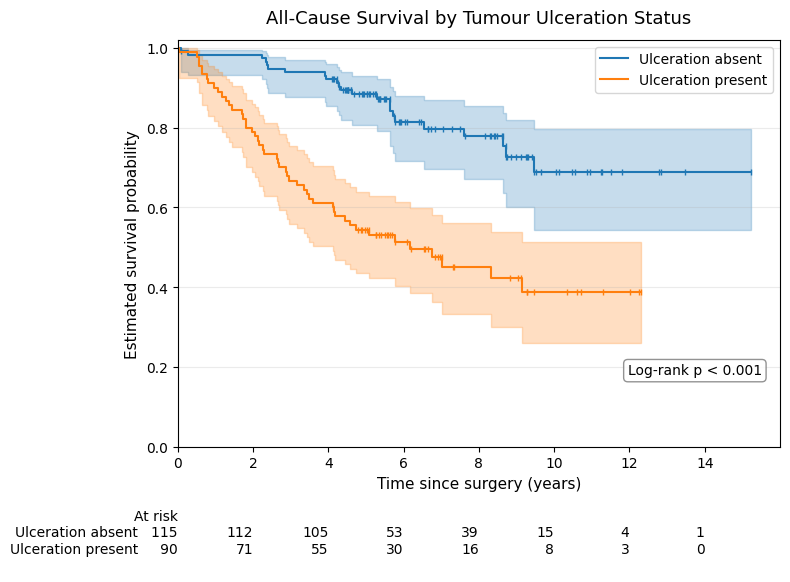

Saved figure:
outputs/km_all_cause_survival_by_ulceration.png


In [11]:
# Kaplan–Meier comparison of all-cause survival
# by tumour ulceration status

km_ulcer_absent = KaplanMeierFitter(label="Ulceration absent")
km_ulcer_present = KaplanMeierFitter(label="Ulceration present")

km_ulcer_absent.fit(
    durations=ulcer_absent["time_years"],
    event_observed=ulcer_absent["all_cause_event"]
)

km_ulcer_present.fit(
    durations=ulcer_present["time_years"],
    event_observed=ulcer_present["all_cause_event"]
)

# Create the publication-style comparison figure
fig, ax = plt.subplots(figsize=(8, 6))

km_ulcer_absent.plot_survival_function(
    ax=ax,
    ci_show=True,
    show_censors=True,
    censor_styles={
        "marker": "|",
        "ms": 5,
        "mew": 1,
    }
)

km_ulcer_present.plot_survival_function(
    ax=ax,
    ci_show=True,
    show_censors=True,
    censor_styles={
        "marker": "|",
        "ms": 5,
        "mew": 1,
    }
)

ax.set_title(
    "All-Cause Survival by Tumour Ulceration Status",
    fontsize=13,
    pad=12
)
ax.set_xlabel("Time since surgery (years)", fontsize=11)
ax.set_ylabel("Estimated survival probability", fontsize=11)
ax.set_xlim(left=0)
ax.set_ylim(0, 1.02)
ax.grid(axis="y", alpha=0.25)

# Report the log-rank comparison clearly on the figure
ax.text(
    0.97,
    0.17,
    "Log-rank p < 0.001",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "white",
        "edgecolor": "gray",
        "alpha": 0.85,
    },
)

# Add the number of patients still under observation
add_at_risk_counts(
    km_ulcer_absent,
    km_ulcer_present,
    ax=ax,
    rows_to_show=["At risk"]
)

plt.tight_layout()

# Save a repository-ready high-resolution PNG figure
figure_path = outputs_dir / "km_all_cause_survival_by_ulceration.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:")
print(figure_path)

In [12]:
# Summarize Kaplan–Meier survival probabilities
# at selected follow-up times for each ulceration group

selected_times = [1, 3, 5, 10]

km_ulceration_summary = pd.DataFrame(
    {
        "time_years": selected_times,
        "ulceration_absent_survival_probability": [
            float(km_ulcer_absent.predict(t)) for t in selected_times
        ],
        "ulceration_present_survival_probability": [
            float(km_ulcer_present.predict(t)) for t in selected_times
        ],
    }
)

# Add readable percentage columns
km_ulceration_summary["ulceration_absent_survival_percent"] = (
    100 * km_ulceration_summary["ulceration_absent_survival_probability"]
).round(1)

km_ulceration_summary["ulceration_present_survival_percent"] = (
    100 * km_ulceration_summary["ulceration_present_survival_probability"]
).round(1)

# Summarize median survival times
median_absent = km_ulcer_absent.median_survival_time_
median_present = km_ulcer_present.median_survival_time_

median_survival_by_ulceration = pd.DataFrame(
    {
        "ulceration_status": [
            "Absent",
            "Present",
        ],
        "median_all_cause_survival_years": [
            (
                "Not reached during available follow-up"
                if np.isinf(median_absent)
                else f"{median_absent:.3f}"
            ),
            (
                "Not reached during available follow-up"
                if np.isinf(median_present)
                else f"{median_present:.3f}"
            ),
        ],
    }
)

# Save repository-ready CSV tables
km_ulceration_summary.to_csv(
    outputs_dir / "km_survival_probabilities_by_ulceration.csv",
    index=False
)

median_survival_by_ulceration.to_csv(
    outputs_dir / "km_median_survival_by_ulceration.csv",
    index=False
)

print("KAPLAN–MEIER SURVIVAL PROBABILITIES BY ULCERATION STATUS")
display(km_ulceration_summary)

print("\nMEDIAN ALL-CAUSE SURVIVAL BY ULCERATION STATUS")
display(median_survival_by_ulceration)

print("\nSaved files:")
print(outputs_dir / "km_survival_probabilities_by_ulceration.csv")
print(outputs_dir / "km_median_survival_by_ulceration.csv")

KAPLAN–MEIER SURVIVAL PROBABILITIES BY ULCERATION STATUS


,time_years,ulceration_absent_survival_probability,ulceration_present_survival_probability,ulceration_absent_survival_percent,ulceration_present_survival_percent
0,1,0.983,0.900,98.300,90.000
1,3,0.939,0.667,93.900,66.700
2,5,0.883,0.543,88.300,54.300
3,10,0.689,0.387,68.900,38.700



MEDIAN ALL-CAUSE SURVIVAL BY ULCERATION STATUS


,ulceration_status,median_all_cause_survival_years
0,Absent,Not reached during available follow-up
1,Present,6.177



Saved files:
outputs/km_survival_probabilities_by_ulceration.csv
outputs/km_median_survival_by_ulceration.csv


---

## 7. Cox Proportional-Hazards Modeling

Kaplan–Meier curves describe unadjusted survival patterns. A Cox proportional-hazards model will now be used to evaluate whether clinically relevant patient and tumour characteristics remain associated with all-cause mortality after accounting for the other selected predictors.

### Primary Outcome

The Cox model will evaluate time from melanoma surgery to death from any cause:

* `all_cause_event = 1` for an observed death,
* `all_cause_event = 0` for a censored observation.

### Parsimonious Predictor Set

The adjusted model will include a focused set of clinically interpretable predictors:

* age at surgery,
* patient sex,
* year of surgery,
* tumour thickness,
* and tumour ulceration status.

The dataset contains 71 observed all-cause deaths. Model complexity will therefore remain intentionally limited to avoid unstable estimates and overfitting.

### Clinically Interpretable Transformations

Age will be expressed per 10-year increase to improve interpretability.

Tumour thickness is positively skewed and its clinical effect may not be well represented by a one-millimetre linear increase across the full observed range. A base-2 logarithmic transformation will therefore be used so that the estimated hazard ratio represents the association with each doubling of tumour thickness.

Year of surgery will be centered at the sample mean to improve numerical readability without changing the estimated association.

### Hazard-Ratio Interpretation

The Cox model estimates hazard ratios rather than absolute risks:

* a hazard ratio above `1` indicates a higher instantaneous rate of all-cause mortality,
* a hazard ratio below `1` indicates a lower instantaneous rate,
* and a hazard ratio of `1` indicates no estimated difference in the hazard.

These estimates describe adjusted prognostic associations. They should not be interpreted as causal effects.

### Proportional-Hazards Assumption

The Cox model assumes that each covariate has a proportional effect on the hazard over time. This assumption will be evaluated formally after fitting the model. If meaningful violations are detected, sensitivity analyses or alternative specifications will be considered before drawing conclusions.


In [13]:
# Prepare a transparent modeling dataframe for the primary Cox analysis

cox_df = melanoma[
    [
        "time_years",
        "all_cause_event",
        "age",
        "sex",
        "year",
        "thickness",
        "ulcer",
    ]
].copy()

# Clinically interpretable transformations
cox_df["age_per_10_years"] = cox_df["age"] / 10
cox_df["male_sex"] = cox_df["sex"].astype(int)
cox_df["surgery_year_centered"] = cox_df["year"] - cox_df["year"].mean()
cox_df["log2_tumour_thickness"] = np.log2(cox_df["thickness"])
cox_df["ulceration_present"] = cox_df["ulcer"].astype(int)

# Retain only the variables required for model fitting
cox_model_df = cox_df[
    [
        "time_years",
        "all_cause_event",
        "age_per_10_years",
        "male_sex",
        "surgery_year_centered",
        "log2_tumour_thickness",
        "ulceration_present",
    ]
].copy()

# Basic verification checks
assert cox_model_df.isna().sum().sum() == 0
assert np.isfinite(cox_model_df).all().all()
assert cox_model_df["time_years"].gt(0).all()

# Save the reproducible analysis-ready modeling dataset
cox_model_df.to_csv(
    outputs_dir / "cox_primary_model_dataset.csv",
    index=False
)

print("PRIMARY COX MODELING DATASET PREPARED SUCCESSFULLY")
print(f"Patients included: {cox_model_df.shape[0]}")
print(f"Observed all-cause deaths: {int(cox_model_df['all_cause_event'].sum())}")
print(f"Predictors included: {cox_model_df.shape[1] - 2}")

print("\nFIRST FIVE ROWS")
display(cox_model_df.head())

print("\nMODELING-VARIABLE SUMMARY")
display(
    cox_model_df.describe().T
)

print("\nSaved file:")
print(outputs_dir / "cox_primary_model_dataset.csv")

PRIMARY COX MODELING DATASET PREPARED SUCCESSFULLY
Patients included: 205
Observed all-cause deaths: 71
Predictors included: 5

FIRST FIVE ROWS


,time_years,all_cause_event,age_per_10_years,male_sex,surgery_year_centered,log2_tumour_thickness,ulceration_present
0,0.027,1,7.600,1,2.093,2.757,1
1,0.082,1,5.600,1,-1.907,-0.621,0
2,0.096,0,4.100,1,7.093,0.422,0
3,0.271,1,7.100,0,-1.907,1.536,0
4,0.507,1,5.200,1,-4.907,3.595,1



MODELING-VARIABLE SUMMARY


,count,mean,std,min,25%,50%,75%,max
time_years,205.000,5.894,3.072,0.027,4.175,5.489,8.329,15.236
all_cause_event,205.000,0.346,0.477,0.000,0.000,0.000,1.000,1.000
age_per_10_years,205.000,5.246,1.667,0.400,4.200,5.400,6.500,9.500
male_sex,205.000,0.385,0.488,0.000,0.000,0.000,1.000,1.000
surgery_year_centered,205.000,-0.000,2.576,-7.907,-1.907,0.093,2.093,7.093
log2_tumour_thickness,205.000,0.892,1.460,-3.322,-0.044,0.956,1.832,4.123
ulceration_present,205.000,0.439,0.497,0.000,0.000,0.000,1.000,1.000



Saved file:
outputs/cox_primary_model_dataset.csv


In [14]:
# Fit the primary multivariable Cox proportional-hazards model

cox_primary = CoxPHFitter()

cox_primary.fit(
    cox_model_df,
    duration_col="time_years",
    event_col="all_cause_event",
    show_progress=False
)

# Create readable clinical labels for the hazard-ratio table
covariate_labels = {
    "age_per_10_years": "Age: per 10-year increase",
    "male_sex": "Male sex: versus female",
    "surgery_year_centered": "Year of surgery: per 1-year increase",
    "log2_tumour_thickness": "Tumour thickness: per doubling",
    "ulceration_present": "Tumour ulceration: present versus absent",
}

# Extract the publication-ready hazard-ratio summary
cox_hr_summary = (
    cox_primary.summary[
        [
            "exp(coef)",
            "exp(coef) lower 95%",
            "exp(coef) upper 95%",
            "p",
        ]
    ]
    .rename(
        columns={
            "exp(coef)": "hazard_ratio",
            "exp(coef) lower 95%": "ci_95_lower",
            "exp(coef) upper 95%": "ci_95_upper",
            "p": "p_value",
        }
    )
    .reset_index()
    .rename(columns={"covariate": "variable"})
)

cox_hr_summary["clinical_interpretation"] = (
    cox_hr_summary["variable"].map(covariate_labels)
)

cox_hr_summary = cox_hr_summary[
    [
        "variable",
        "clinical_interpretation",
        "hazard_ratio",
        "ci_95_lower",
        "ci_95_upper",
        "p_value",
    ]
]

# Save the repository-ready hazard-ratio table
cox_hr_summary.to_csv(
    outputs_dir / "cox_primary_hazard_ratio_summary.csv",
    index=False
)

print("PRIMARY COX PROPORTIONAL-HAZARDS MODEL")
print(f"Patients included: {cox_primary._n_examples}")
print(f"Observed all-cause deaths: {int(cox_model_df['all_cause_event'].sum())}")
print(f"Concordance index: {cox_primary.concordance_index_:.3f}")
print(f"Partial AIC: {cox_primary.AIC_partial_:.3f}")

print("\nADJUSTED HAZARD-RATIO SUMMARY")
display(cox_hr_summary)

print("\nSaved file:")
print(outputs_dir / "cox_primary_hazard_ratio_summary.csv")

PRIMARY COX PROPORTIONAL-HAZARDS MODEL
Patients included: 205
Observed all-cause deaths: 71
Concordance index: 0.740
Partial AIC: 659.763

ADJUSTED HAZARD-RATIO SUMMARY


,variable,clinical_interpretation,hazard_ratio,ci_95_lower,ci_95_upper,p_value
0,age_per_10_years,Age: per 10-year increase,1.280,1.096,1.494,0.002
1,male_sex,Male sex: versus female,1.486,0.925,2.388,0.101
2,surgery_year_centered,Year of surgery: per 1-year increase,0.918,0.825,1.022,0.119
3,log2_tumour_thickness,Tumour thickness: per doubling,1.320,1.066,1.633,0.011
4,ulceration_present,Tumour ulceration: present versus absent,2.315,1.333,4.019,0.003



Saved file:
outputs/cox_primary_hazard_ratio_summary.csv


---

## 8. Proportional-Hazards Diagnostics

The Cox proportional-hazards model assumes that the relative hazard associated with each predictor remains approximately constant over follow-up time. This assumption must be evaluated before the adjusted hazard-ratio estimates are interpreted as the primary model findings.

### Diagnostic Strategy

The proportional-hazards assumption will be assessed using Schoenfeld-residual-based diagnostics. The evaluation will include:

* covariate-specific statistical tests,
* a global proportional-hazards assessment,
* inspection of diagnostic output for potential time-varying effects,
* and careful consideration of whether any detected violation is clinically meaningful.

### Interpretation Principle

A statistically significant diagnostic result does not automatically invalidate the complete Cox model. The magnitude of the concern, the affected variable, the sample size, and the clinical interpretation must be considered together.

If a meaningful proportional-hazards violation is detected, an appropriate sensitivity analysis will be performed. Possible responses include:

* stratification,
* a time-varying effect specification,
* or a transparent comparison with an alternative Cox-model formulation.

### Modeling Boundary

The primary Cox model is intentionally parsimonious and clinically interpretable. Diagnostic decisions will be guided by both statistical evidence and interpretability rather than by mechanical model modification.


In [15]:
# Run Schoenfeld-residual-based proportional-hazards diagnostics
# using two common transformations of follow-up time

from lifelines.statistics import proportional_hazard_test

ph_test = proportional_hazard_test(
    fitted_cox_model=cox_primary,
    training_df=cox_model_df,
    time_transform=["rank", "km"],
)

# Convert the lifelines output into a clean repository-ready table
ph_test_summary = (
    ph_test.summary
    .reset_index()
    .rename(
        columns={
            "level_0": "variable",
            "level_1": "time_transform",
            "p": "p_value",
            "-log2(p)": "negative_log2_p_value",
        }
    )
)

# Flag results below the conventional diagnostic threshold
ph_test_summary["flag_p_lt_0_05"] = (
    ph_test_summary["p_value"] < 0.05
)

# Create a compact variable-level screening summary
ph_variable_screening = (
    ph_test_summary
    .groupby("variable", as_index=False)
    .agg(
        minimum_p_value=("p_value", "min"),
        flagged_by_any_test=("flag_p_lt_0_05", "any"),
    )
)

# Save repository-ready CSV tables
ph_test_summary.to_csv(
    outputs_dir / "cox_ph_schoenfeld_test_details.csv",
    index=False
)

ph_variable_screening.to_csv(
    outputs_dir / "cox_ph_variable_screening_summary.csv",
    index=False
)

print("SCHOENFELD-RESIDUAL PROPORTIONAL-HAZARDS TESTS")
display(ph_test_summary)

print("\nVARIABLE-LEVEL SCREENING SUMMARY")
display(ph_variable_screening)

print("\nSaved files:")
print(outputs_dir / "cox_ph_schoenfeld_test_details.csv")
print(outputs_dir / "cox_ph_variable_screening_summary.csv")

SCHOENFELD-RESIDUAL PROPORTIONAL-HAZARDS TESTS


,variable,time_transform,test_statistic,p_value,negative_log2_p_value,flag_p_lt_0_05
0,age_per_10_years,km,1.918,0.166,2.590,False
1,age_per_10_years,rank,1.781,0.182,2.458,False
2,log2_tumour_thickness,km,0.797,0.372,1.427,False
3,log2_tumour_thickness,rank,0.855,0.355,1.494,False
4,male_sex,km,0.167,0.683,0.550,False
5,male_sex,rank,0.199,0.656,0.609,False
6,surgery_year_centered,km,0.108,0.743,0.429,False
7,surgery_year_centered,rank,0.105,0.746,0.423,False
8,ulceration_present,km,2.365,0.124,3.011,False
9,ulceration_present,rank,2.295,0.130,2.946,False



VARIABLE-LEVEL SCREENING SUMMARY


,variable,minimum_p_value,flagged_by_any_test
0,age_per_10_years,0.166,False
1,log2_tumour_thickness,0.355,False
2,male_sex,0.656,False
3,surgery_year_centered,0.743,False
4,ulceration_present,0.124,False



Saved files:
outputs/cox_ph_schoenfeld_test_details.csv
outputs/cox_ph_variable_screening_summary.csv


### Numerical Proportional-Hazards Diagnostic Findings

Schoenfeld-residual-based proportional-hazards tests were evaluated using both rank-based and Kaplan–Meier-based transformations of follow-up time.

None of the selected covariates produced a diagnostic p-value below `0.05` under either transformation. The smallest observed p-value was `0.124` for tumour ulceration status.

The formal screening therefore did not identify clear evidence of a proportional-hazards violation for:

* age,
* sex,
* year of surgery,
* tumour thickness,
* or tumour ulceration status.

### Interpretation Boundary

A non-significant diagnostic result does not prove that the proportional-hazards assumption is perfectly satisfied. Statistical tests may have limited power, particularly in modest clinical datasets. Numerical findings should therefore be considered alongside visual inspection of scaled Schoenfeld residual patterns.

The primary Cox model will be retained provisionally while visual diagnostic plots are reviewed.


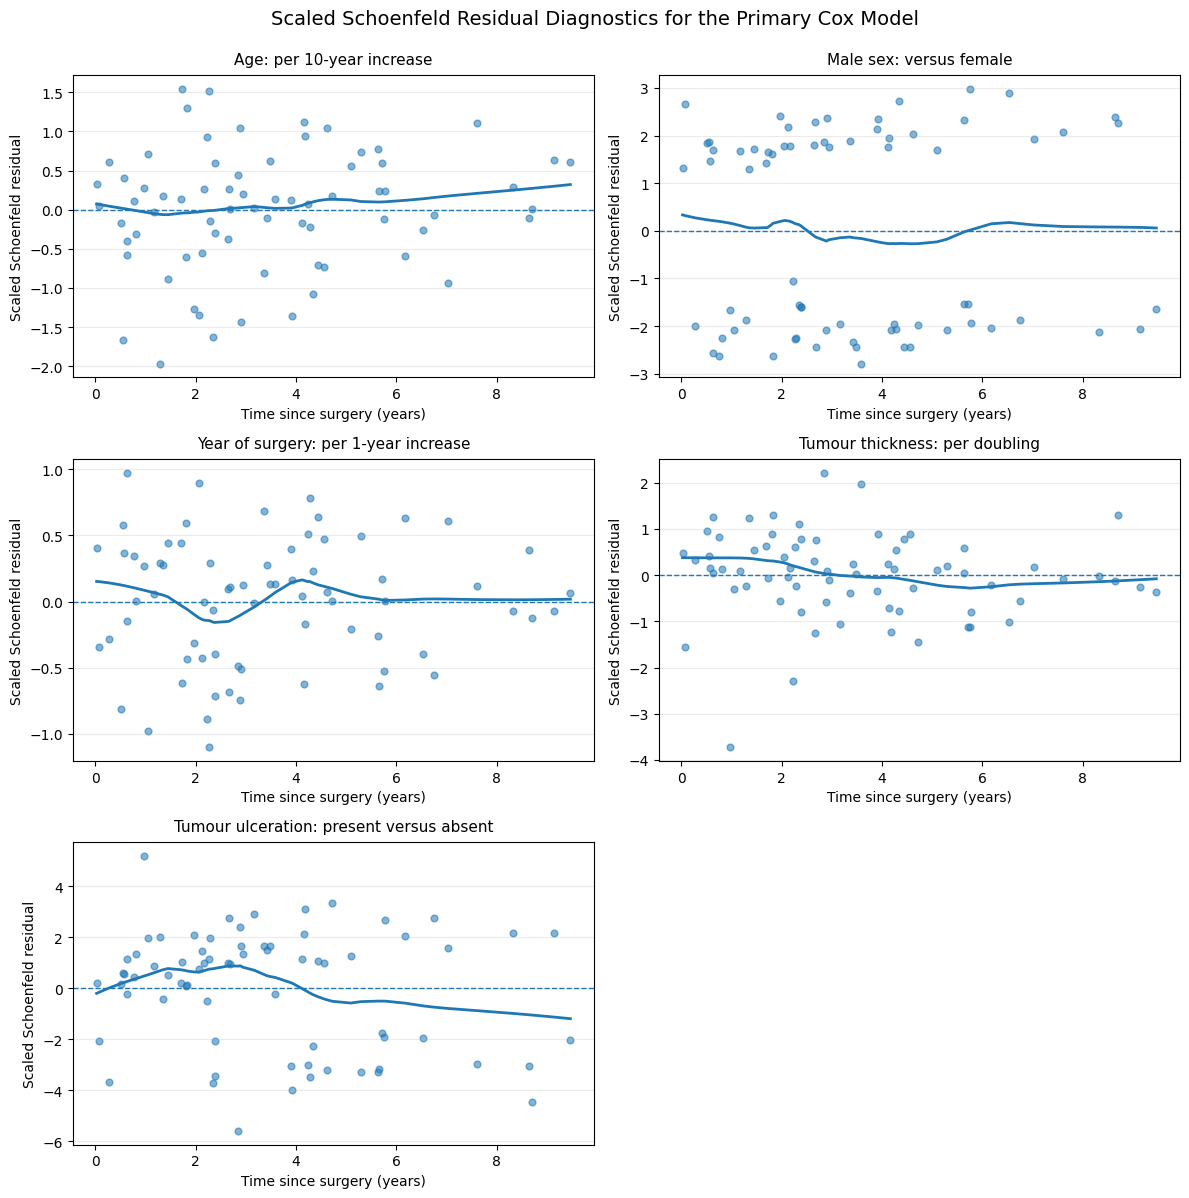

Saved figure:
outputs/cox_scaled_schoenfeld_residual_diagnostics.png


In [16]:
# Visual proportional-hazards diagnostics using scaled Schoenfeld residuals

from statsmodels.nonparametric.smoothers_lowess import lowess

# Compute scaled Schoenfeld residuals for observed all-cause deaths
scaled_schoenfeld = cox_primary.compute_residuals(
    cox_model_df,
    kind="scaled_schoenfeld"
).copy()

# Add the corresponding observed event times
scaled_schoenfeld["time_years"] = cox_model_df.loc[
    scaled_schoenfeld.index,
    "time_years"
].values

diagnostic_variables = [
    "age_per_10_years",
    "male_sex",
    "surgery_year_centered",
    "log2_tumour_thickness",
    "ulceration_present",
]

diagnostic_labels = {
    "age_per_10_years": "Age: per 10-year increase",
    "male_sex": "Male sex: versus female",
    "surgery_year_centered": "Year of surgery: per 1-year increase",
    "log2_tumour_thickness": "Tumour thickness: per doubling",
    "ulceration_present": "Tumour ulceration: present versus absent",
}

# Create a multi-panel publication-style diagnostic figure
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 12)
)

axes = axes.flatten()

for ax, variable in zip(axes, diagnostic_variables):
    plot_df = (
        scaled_schoenfeld[
            ["time_years", variable]
        ]
        .dropna()
        .sort_values("time_years")
    )

    # Plot individual scaled Schoenfeld residuals
    ax.scatter(
        plot_df["time_years"],
        plot_df[variable],
        alpha=0.55,
        s=24,
        label="Scaled Schoenfeld residual"
    )

    # Add a LOWESS smooth to inspect potential time-varying patterns
    smooth = lowess(
        endog=plot_df[variable],
        exog=plot_df["time_years"],
        frac=0.50,
        return_sorted=True
    )

    ax.plot(
        smooth[:, 0],
        smooth[:, 1],
        linewidth=2,
        label="LOWESS smooth"
    )

    # Horizontal reference line for no systematic time trend
    ax.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        diagnostic_labels[variable],
        fontsize=11,
        pad=8
    )

    ax.set_xlabel(
        "Time since surgery (years)",
        fontsize=10
    )

    ax.set_ylabel(
        "Scaled Schoenfeld residual",
        fontsize=10
    )

    ax.grid(
        axis="y",
        alpha=0.25
    )

# Remove the unused sixth panel
fig.delaxes(axes[-1])

fig.suptitle(
    "Scaled Schoenfeld Residual Diagnostics for the Primary Cox Model",
    fontsize=14,
    y=0.995
)

plt.tight_layout()

# Save a repository-ready high-resolution PNG figure
figure_path = outputs_dir / "cox_scaled_schoenfeld_residual_diagnostics.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:")
print(figure_path)

### Visual Proportional-Hazards Diagnostic Findings

Scaled Schoenfeld residual plots were reviewed alongside the numerical proportional-hazards tests.

For age, sex, year of surgery, and tumour thickness, the smoothed residual patterns did not reveal a strong or persistent departure from the horizontal reference line. Minor local fluctuations were present, as expected in a dataset of this size, but no pronounced systematic time trend was evident.

For tumour ulceration status, the LOWESS smooth suggested a modest downward drift during later follow-up. This pattern may indicate that the relative hazard associated with ulceration becomes less pronounced over time. However, the corresponding formal diagnostic tests were not statistically significant (`p = 0.124` and `p = 0.130`), and fewer patients remained under observation during the later follow-up period.

### Diagnostic Conclusion

Taken together, the numerical and visual diagnostics do not provide strong evidence that the primary Cox proportional-hazards model is invalid. The model will therefore be retained as the main adjusted analysis.

Nevertheless, because tumour ulceration is a clinically important predictor and its visual residual pattern suggests possible temporal variation, a focused sensitivity analysis will be performed. This additional analysis will assess whether the estimated ulceration association remains qualitatively consistent across earlier and later follow-up periods.

### Interpretation Boundary

The sensitivity analysis is intended as a robustness check rather than a data-driven attempt to force a more complex model. Findings will be interpreted cautiously, particularly during later follow-up when fewer patients remain at risk.


---

## 9. Sensitivity Analysis: Possible Time Variation in the Ulceration Association

The primary Cox model assumes that the adjusted hazard ratio associated with tumour ulceration remains approximately constant throughout follow-up. Numerical Schoenfeld-residual tests did not identify a statistically significant violation of this assumption. However, the visual diagnostic plot suggested a modest downward drift in the ulceration residual pattern during later follow-up.

A focused exploratory sensitivity analysis will therefore examine whether the ulceration association differs between earlier and later follow-up periods.

### Piecewise Follow-Up Definition

Follow-up will be divided into two clinically interpretable intervals:

* **earlier follow-up:** from surgery through 5 years,
* **later follow-up:** beyond 5 years.

The 5-year threshold is used as a pragmatic exploratory landmark because it provides an interpretable clinical time horizon and reflects the region where the visual residual pattern begins to suggest possible attenuation.

### Time-Varying Cox Sensitivity Model

A start–stop survival dataset will be created so that each patient contributes observation time to the appropriate follow-up interval. A time-varying Cox model will then include:

* age at surgery,
* sex,
* year of surgery,
* tumour thickness,
* tumour ulceration status,
* and an interaction between tumour ulceration and the later follow-up interval.

This formulation allows the ulceration hazard ratio to differ after 5 years while retaining the same focused adjustment set used in the primary Cox model.

### Interpretation Principle

The sensitivity analysis is exploratory rather than confirmatory. The dataset contains a limited number of deaths, particularly during later follow-up. The interval-specific ulceration estimates should therefore be interpreted cautiously, with attention to confidence intervals and the number of patients remaining at risk.

The primary proportional-hazards model will remain the main adjusted analysis unless the sensitivity model reveals a substantial and clinically meaningful change in the interpretation.


In [17]:
# Create a start-stop dataset for the exploratory
# time-varying ulceration sensitivity analysis

landmark_years = 5.0

# Add a stable patient identifier
base_tv_df = cox_model_df.reset_index(drop=True).copy()
base_tv_df.insert(
    0,
    "patient_id",
    np.arange(len(base_tv_df))
)

tv_rows = []

for _, row in base_tv_df.iterrows():

    patient_id = int(row["patient_id"])
    observed_time = float(row["time_years"])
    observed_event = int(row["all_cause_event"])

    common_covariates = {
        "age_per_10_years": row["age_per_10_years"],
        "male_sex": row["male_sex"],
        "surgery_year_centered": row["surgery_year_centered"],
        "log2_tumour_thickness": row["log2_tumour_thickness"],
        "ulceration_present": row["ulceration_present"],
    }

    # Patients with follow-up ending within 5 years
    # contribute one earlier-interval row
    if observed_time <= landmark_years:

        tv_rows.append(
            {
                "patient_id": patient_id,
                "start": 0.0,
                "stop": observed_time,
                "event": observed_event,
                "later_followup": 0,
                **common_covariates,
            }
        )

    # Patients followed beyond 5 years contribute:
    # one earlier-interval row and one later-interval row
    else:

        tv_rows.append(
            {
                "patient_id": patient_id,
                "start": 0.0,
                "stop": landmark_years,
                "event": 0,
                "later_followup": 0,
                **common_covariates,
            }
        )

        tv_rows.append(
            {
                "patient_id": patient_id,
                "start": landmark_years,
                "stop": observed_time,
                "event": observed_event,
                "later_followup": 1,
                **common_covariates,
            }
        )

# Combine all episodic records
cox_tv_df = pd.DataFrame(tv_rows)

# Create the time-varying interaction term:
# this allows the ulceration association to change after 5 years
cox_tv_df["ulceration_after_5_years"] = (
    cox_tv_df["ulceration_present"]
    * cox_tv_df["later_followup"]
)

# Add a readable interval label for the audit table
cox_tv_df["followup_interval"] = (
    cox_tv_df["later_followup"]
    .map(
        {
            0: "0 to 5 years",
            1: "Beyond 5 years",
        }
    )
)

# Calculate the contributed time within each row
cox_tv_df["interval_duration_years"] = (
    cox_tv_df["stop"] - cox_tv_df["start"]
)

# Verify the start-stop structure
assert cox_tv_df["interval_duration_years"].gt(0).all()
assert cox_tv_df["patient_id"].nunique() == len(melanoma)
assert int(cox_tv_df["event"].sum()) == int(melanoma["all_cause_event"].sum())
assert (
    cox_tv_df
    .groupby("patient_id")["event"]
    .sum()
    .le(1)
    .all()
)

# Create an interval-level audit table
tv_interval_summary = (
    cox_tv_df
    .groupby(
        "followup_interval",
        sort=False
    )
    .agg(
        rows_n=("patient_id", "size"),
        patients_contributing_n=("patient_id", "nunique"),
        observed_deaths_n=("event", "sum"),
        contributed_person_years=("interval_duration_years", "sum"),
    )
    .reset_index()
)

# Save repository-ready CSV files
cox_tv_df.to_csv(
    outputs_dir / "cox_time_varying_ulceration_dataset.csv",
    index=False
)

tv_interval_summary.to_csv(
    outputs_dir / "cox_time_varying_interval_summary.csv",
    index=False
)

# Select one split patient to illustrate the start-stop structure
split_candidates = cox_tv_df.loc[
    (cox_tv_df["later_followup"] == 1)
    & (cox_tv_df["ulceration_present"] == 1),
    "patient_id"
]

if len(split_candidates) == 0:
    split_candidates = cox_tv_df.loc[
        cox_tv_df["later_followup"] == 1,
        "patient_id"
    ]

example_patient_id = int(split_candidates.iloc[0])

print("START-STOP DATASET CREATED SUCCESSFULLY")
print(f"Unique patients: {cox_tv_df['patient_id'].nunique()}")
print(f"Total episodic rows: {len(cox_tv_df)}")
print(f"Observed all-cause deaths retained: {int(cox_tv_df['event'].sum())}")

print("\nFOLLOW-UP INTERVAL SUMMARY")
display(tv_interval_summary)

print("\nEXAMPLE OF A PATIENT CONTRIBUTING TO BOTH INTERVALS")
display(
    cox_tv_df.loc[
        cox_tv_df["patient_id"] == example_patient_id,
        [
            "patient_id",
            "start",
            "stop",
            "event",
            "later_followup",
            "ulceration_present",
            "ulceration_after_5_years",
        ],
    ]
)

print("\nSaved files:")
print(outputs_dir / "cox_time_varying_ulceration_dataset.csv")
print(outputs_dir / "cox_time_varying_interval_summary.csv")

START-STOP DATASET CREATED SUCCESSFULLY
Unique patients: 205
Total episodic rows: 327
Observed all-cause deaths retained: 71

FOLLOW-UP INTERVAL SUMMARY


,followup_interval,rows_n,patients_contributing_n,observed_deaths_n,contributed_person_years
0,0 to 5 years,205,205,54,866.931
1,Beyond 5 years,122,122,17,341.348



EXAMPLE OF A PATIENT CONTRIBUTING TO BOTH INTERVALS


,patient_id,start,stop,event,later_followup,ulceration_present,ulceration_after_5_years
87,85,0.000,5.000,0,0,1.000,0.000
88,85,5.000,5.035,0,1,1.000,1.000



Saved files:
outputs/cox_time_varying_ulceration_dataset.csv
outputs/cox_time_varying_interval_summary.csv


In [18]:
# Fit the exploratory time-varying Cox sensitivity model

from lifelines import CoxTimeVaryingFitter
from scipy.stats import norm

# Retain only the variables needed for fitting
cox_tv_model_df = cox_tv_df[
    [
        "patient_id",
        "start",
        "stop",
        "event",
        "age_per_10_years",
        "male_sex",
        "surgery_year_centered",
        "log2_tumour_thickness",
        "ulceration_present",
        "ulceration_after_5_years",
    ]
].copy()

# Fit the time-varying Cox model
cox_tv_model = CoxTimeVaryingFitter()

cox_tv_model.fit(
    cox_tv_model_df,
    id_col="patient_id",
    start_col="start",
    stop_col="stop",
    event_col="event",
    show_progress=False,
)

# Create readable labels for the model terms
tv_covariate_labels = {
    "age_per_10_years": "Age: per 10-year increase",
    "male_sex": "Male sex: versus female",
    "surgery_year_centered": "Year of surgery: per 1-year increase",
    "log2_tumour_thickness": "Tumour thickness: per doubling",
    "ulceration_present": "Tumour ulceration during 0 to 5 years",
    "ulceration_after_5_years": "Additional ulceration association beyond 5 years",
}

# Extract the full model summary
cox_tv_hr_summary = (
    cox_tv_model.summary[
        [
            "coef",
            "exp(coef)",
            "exp(coef) lower 95%",
            "exp(coef) upper 95%",
            "p",
        ]
    ]
    .rename(
        columns={
            "coef": "log_hazard_ratio",
            "exp(coef)": "hazard_ratio",
            "exp(coef) lower 95%": "ci_95_lower",
            "exp(coef) upper 95%": "ci_95_upper",
            "p": "p_value",
        }
    )
    .reset_index()
    .rename(columns={"covariate": "variable"})
)

cox_tv_hr_summary["clinical_interpretation"] = (
    cox_tv_hr_summary["variable"].map(tv_covariate_labels)
)

cox_tv_hr_summary = cox_tv_hr_summary[
    [
        "variable",
        "clinical_interpretation",
        "log_hazard_ratio",
        "hazard_ratio",
        "ci_95_lower",
        "ci_95_upper",
        "p_value",
    ]
]

# Calculate interval-specific ulceration hazard ratios
beta_early = cox_tv_model.params_["ulceration_present"]
beta_interaction = cox_tv_model.params_["ulceration_after_5_years"]
beta_late = beta_early + beta_interaction

variance_matrix = cox_tv_model.variance_matrix_.copy()
variance_matrix.index = list(cox_tv_model.params_.index)
variance_matrix.columns = list(cox_tv_model.params_.index)

variance_early = variance_matrix.loc[
    "ulceration_present",
    "ulceration_present"
]

variance_late = (
    variance_matrix.loc[
        "ulceration_present",
        "ulceration_present"
    ]
    + variance_matrix.loc[
        "ulceration_after_5_years",
        "ulceration_after_5_years"
    ]
    + 2
    * variance_matrix.loc[
        "ulceration_present",
        "ulceration_after_5_years"
    ]
)

se_early = np.sqrt(variance_early)
se_late = np.sqrt(variance_late)

interval_specific_ulceration_summary = pd.DataFrame(
    {
        "followup_interval": [
            "0 to 5 years",
            "Beyond 5 years",
        ],
        "log_hazard_ratio": [
            beta_early,
            beta_late,
        ],
        "hazard_ratio": [
            np.exp(beta_early),
            np.exp(beta_late),
        ],
        "ci_95_lower": [
            np.exp(beta_early - 1.96 * se_early),
            np.exp(beta_late - 1.96 * se_late),
        ],
        "ci_95_upper": [
            np.exp(beta_early + 1.96 * se_early),
            np.exp(beta_late + 1.96 * se_late),
        ],
        "p_value": [
            2 * norm.sf(abs(beta_early / se_early)),
            2 * norm.sf(abs(beta_late / se_late)),
        ],
    }
)

# Save repository-ready CSV tables
cox_tv_hr_summary.to_csv(
    outputs_dir / "cox_time_varying_model_summary.csv",
    index=False
)

interval_specific_ulceration_summary.to_csv(
    outputs_dir / "cox_ulceration_interval_specific_hazard_ratios.csv",
    index=False
)

print("EXPLORATORY TIME-VARYING COX SENSITIVITY MODEL")
print(f"Unique patients: {cox_tv_model_df['patient_id'].nunique()}")
print(f"Episodic rows: {len(cox_tv_model_df)}")
print(f"Observed all-cause deaths: {int(cox_tv_model_df['event'].sum())}")

print("\nFULL TIME-VARYING COX MODEL SUMMARY")
display(cox_tv_hr_summary)

print("\nINTERVAL-SPECIFIC ULCERATION HAZARD RATIOS")
display(interval_specific_ulceration_summary)

print("\nULCERATION INTERACTION TEST")
print(
    "Interaction HR modifier beyond 5 years: "
    f"{np.exp(beta_interaction):.3f}"
)
print(
    "Interaction p-value: "
    f"{cox_tv_model.summary.loc['ulceration_after_5_years', 'p']:.4f}"
)

print("\nSaved files:")
print(outputs_dir / "cox_time_varying_model_summary.csv")
print(outputs_dir / "cox_ulceration_interval_specific_hazard_ratios.csv")

EXPLORATORY TIME-VARYING COX SENSITIVITY MODEL
Unique patients: 205
Episodic rows: 327
Observed all-cause deaths: 71

FULL TIME-VARYING COX MODEL SUMMARY


,variable,clinical_interpretation,log_hazard_ratio,hazard_ratio,ci_95_lower,ci_95_upper,p_value
0,age_per_10_years,Age: per 10-year increase,0.237,1.267,1.085,1.480,0.003
1,male_sex,Male sex: versus female,0.390,1.477,0.919,2.374,0.108
2,surgery_year_centered,Year of surgery: per 1-year increase,-0.080,0.923,0.829,1.027,0.142
3,log2_tumour_thickness,Tumour thickness: per doubling,0.281,1.324,1.068,1.641,0.011
4,ulceration_present,Tumour ulceration during 0 to 5 years,1.163,3.201,1.641,6.242,0.001
5,ulceration_after_5_years,Additional ulceration association beyond 5 years,-1.155,0.315,0.099,1.001,0.050



INTERVAL-SPECIFIC ULCERATION HAZARD RATIOS


,followup_interval,log_hazard_ratio,hazard_ratio,ci_95_lower,ci_95_upper,p_value
0,0 to 5 years,1.163,3.201,1.641,6.242,0.001
1,Beyond 5 years,0.009,1.009,0.371,2.740,0.987



ULCERATION INTERACTION TEST
Interaction HR modifier beyond 5 years: 0.315
Interaction p-value: 0.0502

Saved files:
outputs/cox_time_varying_model_summary.csv
outputs/cox_ulceration_interval_specific_hazard_ratios.csv


### Sensitivity-Analysis Findings

The exploratory time-varying Cox model suggested that the adjusted association between tumour ulceration and all-cause mortality may be stronger during earlier follow-up than during later follow-up.

During the first 5 years after surgery, the presence of tumour ulceration was associated with an estimated `3.20`-fold higher all-cause mortality hazard (`95% CI: 1.64–6.24`, `p = 0.001`) after adjustment for age, sex, year of surgery, and tumour thickness.

Beyond 5 years, the interval-specific ulceration estimate was substantially weaker and imprecise (`HR = 1.01`, `95% CI: 0.37–2.74`, `p = 0.987`).

The interaction term representing the additional modification of the ulceration association beyond 5 years was borderline (`HR modifier = 0.315`, `p = 0.0502`).

### Interpretation Boundary

These results should be interpreted as exploratory evidence of possible attenuation rather than definitive proof of a time-varying ulceration effect.

Only 17 all-cause deaths occurred after 5 years, limiting the precision of the later-period estimate. The 5-year threshold was also selected as a pragmatic and clinically interpretable landmark for sensitivity analysis rather than as a prespecified confirmatory cut-point.

The parsimonious proportional-hazards model will therefore remain the primary adjusted analysis. The time-varying model serves as a robustness check that documents a potentially important clinical pattern while preserving an appropriately cautious interpretation.


---

## 10. Adjusted Hazard-Ratio Summary

The primary Cox proportional-hazards model provides adjusted estimates of the association between selected patient and tumour characteristics and the hazard of all-cause mortality after melanoma surgery.

A forest plot will be used to present the hazard-ratio estimates, 95% confidence intervals, and reference value of `HR = 1` in a clinically interpretable visual format.

### Interpretation Guide

* A hazard ratio above `1` indicates a higher estimated all-cause mortality hazard.
* A hazard ratio below `1` indicates a lower estimated all-cause mortality hazard.
* A 95% confidence interval crossing `1` indicates that the data do not provide strong evidence of an independent association at the conventional significance threshold.

The estimated hazard ratios represent adjusted prognostic associations rather than causal effects.

### Model Context

The plotted estimates correspond to the parsimonious primary Cox model, which includes:

* age per 10-year increase,
* male sex versus female sex,
* year of surgery per 1-year increase,
* tumour thickness per doubling,
* and tumour ulceration present versus absent.

The exploratory time-varying sensitivity analysis remains an important supplementary finding, but the proportional-hazards model is retained as the primary adjusted analysis for clear and interpretable presentation.


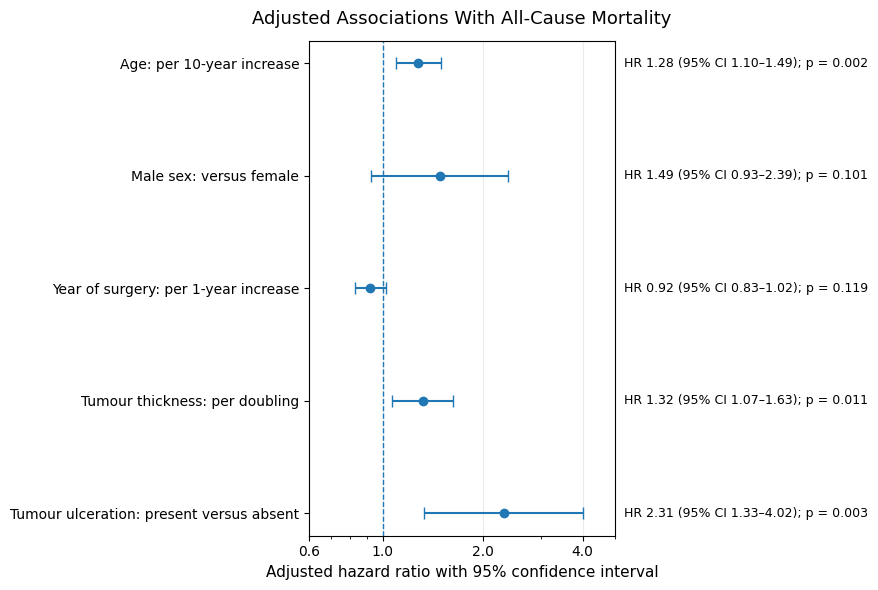

Saved figure:
outputs/cox_primary_hazard_ratio_forest_plot.png


In [19]:
# Create a publication-style forest plot for the primary Cox model

# Preserve a clinically intuitive display order
forest_plot_df = cox_hr_summary.copy()

forest_plot_df["display_label"] = forest_plot_df["clinical_interpretation"]

# Reverse the order so that the first model term appears at the top
forest_plot_df = forest_plot_df.iloc[::-1].reset_index(drop=True)

from matplotlib.ticker import NullFormatter

# Calculate asymmetric confidence-interval distances
lower_error = (
    forest_plot_df["hazard_ratio"]
    - forest_plot_df["ci_95_lower"]
)

upper_error = (
    forest_plot_df["ci_95_upper"]
    - forest_plot_df["hazard_ratio"]
)

# Format p-values clearly
def format_p_value(p_value):
    if p_value < 0.001:
        return "p < 0.001"
    return f"p = {p_value:.3f}"

# Create the figure
fig, ax = plt.subplots(figsize=(9, 6))

y_positions = np.arange(len(forest_plot_df))

ax.errorbar(
    x=forest_plot_df["hazard_ratio"],
    y=y_positions,
    xerr=[lower_error, upper_error],
    fmt="o",
    markersize=6,
    capsize=4,
    linewidth=1.5,
)

# Add the null-reference line
ax.axvline(
    x=1,
    linestyle="--",
    linewidth=1,
)

# Add readable axis labels
ax.set_yticks(y_positions)
ax.set_yticklabels(
    forest_plot_df["display_label"],
    fontsize=10
)

ax.set_xscale("log")
ax.set_xlim(0.6, 5.0)

ax.set_xticks([0.6, 1.0, 2.0, 4.0])
ax.set_xticklabels(["0.6", "1.0", "2.0", "4.0"])

ax.xaxis.set_minor_formatter(NullFormatter())

ax.set_xlabel(
    "Adjusted hazard ratio with 95% confidence interval",
    fontsize=11
)

ax.set_title(
    "Adjusted Associations With All-Cause Mortality",
    fontsize=13,
    pad=12
)

ax.grid(
    axis="x",
    alpha=0.25
)

# Add numerical hazard-ratio summaries to the right of the figure
for y_position, row in forest_plot_df.iterrows():

    annotation = (
        f"HR {row['hazard_ratio']:.2f} "
        f"(95% CI {row['ci_95_lower']:.2f}–{row['ci_95_upper']:.2f}); "
        f"{format_p_value(row['p_value'])}"
    )

    ax.text(
        1.03,
        y_position,
        annotation,
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=9,
    )

plt.tight_layout()

# Save a repository-ready high-resolution PNG figure
figure_path = outputs_dir / "cox_primary_hazard_ratio_forest_plot.png"

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:")
print(figure_path)

---

## 11. Covariate-Standardized Adjusted Survival Curves

The Kaplan–Meier curves presented earlier provide an unadjusted comparison of all-cause survival according to tumour ulceration status. The primary Cox model can now be used to generate adjusted survival curves that account for differences in the other selected prognostic characteristics.

### Standardization Strategy

Rather than selecting a single hypothetical patient profile, the adjusted curves will be estimated using covariate standardization.

For each patient in the observed cohort:

1. the Cox model will predict survival assuming tumour ulceration is absent,
2. the model will predict survival assuming tumour ulceration is present,
3. all other observed patient characteristics will remain unchanged,
4. and the predicted survival probabilities will be averaged across the cohort.

This approach produces two covariate-standardized survival curves:

* estimated survival under an ulceration-absent profile,
* estimated survival under an ulceration-present profile.

### Why Standardization Is Useful

The standardized curves provide a clinically interpretable visual summary of the adjusted model while preserving the observed distributions of:

* age,
* sex,
* year of surgery,
* and tumour thickness.

They complement the hazard-ratio forest plot by translating relative hazard differences into estimated survival probabilities over time.

### Interpretation Boundary

These adjusted curves are model-based prognostic summaries. They should not be interpreted as causal treatment-effect curves or as evidence that changing ulceration status would change an individual patient’s outcome.

Tumour ulceration is a tumour characteristic rather than an intervention. The curves are therefore used to illustrate adjusted prognostic separation under the fitted Cox model.


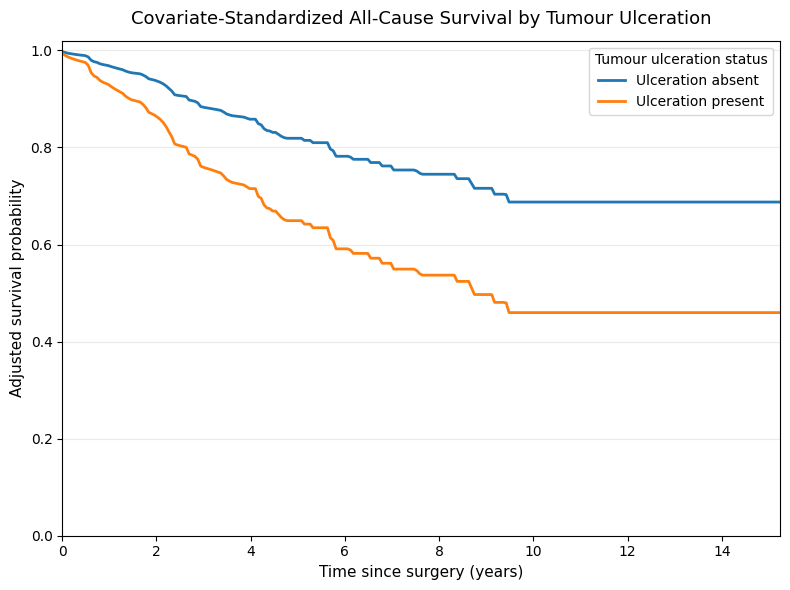

COVARIATE-STANDARDIZED SURVIVAL PROBABILITIES


,time_years,ulceration_absent_standardized_survival,ulceration_present_standardized_survival,ulceration_absent_survival_percent,ulceration_present_survival_percent,absolute_survival_difference_percentage_points
0,1.000,0.968,0.928,96.800,92.800,4.000
1,3.000,0.883,0.759,88.300,75.900,12.400
2,5.000,0.819,0.649,81.900,64.900,17.000
3,10.000,0.687,0.460,68.700,46.000,22.700



Saved files:
outputs/cox_standardized_survival_curves_by_ulceration.png
outputs/cox_standardized_survival_curves_by_ulceration.csv
outputs/cox_standardized_survival_probabilities_by_ulceration.csv


In [20]:
# Create covariate-standardized adjusted survival curves
# for tumour ulceration absent versus present

# Define the predictors used by the primary Cox model
model_covariates = [
    "age_per_10_years",
    "male_sex",
    "surgery_year_centered",
    "log2_tumour_thickness",
    "ulceration_present",
]

# Preserve each patient's observed covariate profile
standardized_absent_df = cox_model_df[
    model_covariates
].copy()

standardized_present_df = cox_model_df[
    model_covariates
].copy()

# Set ulceration status consistently across the cohort
standardized_absent_df["ulceration_present"] = 0
standardized_present_df["ulceration_present"] = 1

# Create a smooth time grid while retaining clinically useful time points
selected_times = [1.0, 3.0, 5.0, 10.0]

time_grid = np.unique(
    np.concatenate(
        [
            np.linspace(
                0,
                melanoma["time_years"].max(),
                250
            ),
            selected_times,
        ]
    )
)

# Predict an adjusted survival curve for each patient
predicted_survival_absent = (
    cox_primary.predict_survival_function(
        standardized_absent_df,
        times=time_grid
    )
)

predicted_survival_present = (
    cox_primary.predict_survival_function(
        standardized_present_df,
        times=time_grid
    )
)

# Average the patient-specific predicted survival probabilities
# across the observed clinical cohort
standardized_survival_curves = pd.DataFrame(
    {
        "time_years": time_grid,
        "ulceration_absent_standardized_survival": (
            predicted_survival_absent.mean(axis=1).values
        ),
        "ulceration_present_standardized_survival": (
            predicted_survival_present.mean(axis=1).values
        ),
    }
)

# Create a concise table at clinically interpretable time points
standardized_survival_summary = (
    standardized_survival_curves.loc[
        standardized_survival_curves["time_years"].isin(
            selected_times
        )
    ]
    .copy()
    .reset_index(drop=True)
)

standardized_survival_summary[
    "ulceration_absent_survival_percent"
] = (
    100
    * standardized_survival_summary[
        "ulceration_absent_standardized_survival"
    ]
).round(1)

standardized_survival_summary[
    "ulceration_present_survival_percent"
] = (
    100
    * standardized_survival_summary[
        "ulceration_present_standardized_survival"
    ]
).round(1)

standardized_survival_summary[
    "absolute_survival_difference_percentage_points"
] = (
    standardized_survival_summary[
        "ulceration_absent_survival_percent"
    ]
    - standardized_survival_summary[
        "ulceration_present_survival_percent"
    ]
).round(1)

# Create the publication-style figure
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(
    standardized_survival_curves["time_years"],
    standardized_survival_curves[
        "ulceration_absent_standardized_survival"
    ],
    linewidth=2,
    label="Ulceration absent",
)

ax.plot(
    standardized_survival_curves["time_years"],
    standardized_survival_curves[
        "ulceration_present_standardized_survival"
    ],
    linewidth=2,
    label="Ulceration present",
)

ax.set_title(
    "Covariate-Standardized All-Cause Survival by Tumour Ulceration",
    fontsize=13,
    pad=12
)

ax.set_xlabel(
    "Time since surgery (years)",
    fontsize=11
)

ax.set_ylabel(
    "Adjusted survival probability",
    fontsize=11
)

ax.set_xlim(
    0,
    melanoma["time_years"].max()
)

ax.set_ylim(
    0,
    1.02
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.legend(
    title="Tumour ulceration status"
)

plt.tight_layout()

# Save repository-ready outputs
figure_path = (
    outputs_dir
    / "cox_standardized_survival_curves_by_ulceration.png"
)

curve_table_path = (
    outputs_dir
    / "cox_standardized_survival_curves_by_ulceration.csv"
)

summary_table_path = (
    outputs_dir
    / "cox_standardized_survival_probabilities_by_ulceration.csv"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

standardized_survival_curves.to_csv(
    curve_table_path,
    index=False
)

standardized_survival_summary.to_csv(
    summary_table_path,
    index=False
)

plt.show()

print("COVARIATE-STANDARDIZED SURVIVAL PROBABILITIES")
display(standardized_survival_summary)

print("\nSaved files:")
print(figure_path)
print(curve_table_path)
print(summary_table_path)

### Adjusted Survival-Curve Findings

The covariate-standardized survival curves showed persistent prognostic separation according to tumour ulceration status after accounting for age, sex, year of surgery, and tumour thickness.

At 5 years after surgery, the estimated standardized all-cause survival probability was:

* `81.9%` under an ulceration-absent profile,
* `64.9%` under an ulceration-present profile.

This corresponds to an adjusted absolute survival difference of `17.0` percentage points.

At 10 years, the estimated standardized survival probabilities were:

* `68.7%` under an ulceration-absent profile,
* `46.0%` under an ulceration-present profile.

The corresponding adjusted absolute survival difference was `22.7` percentage points.

### Interpretation Boundary

These curves are model-based prognostic summaries derived from the primary Cox proportional-hazards model. They are not causal treatment-effect estimates.

The curves should also be interpreted alongside the exploratory time-varying sensitivity analysis, which suggested that the ulceration association may become less pronounced after 5 years. The later separation shown by the primary-model curves should therefore be treated as a useful prognostic summary rather than a definitive representation of a constant long-term association.

The standardized curves complement the adjusted hazard-ratio table by translating relative hazard estimates into clinically interpretable survival probabilities over time.


---

## 12. Competing-Risk Analysis

The conventional all-cause survival analysis evaluates the timing of death from any cause. However, the clinical dataset distinguishes between two mutually exclusive types of mortality:

* death from melanoma,
* death from another cause.

A patient who dies from another cause can no longer experience melanoma-related death. Death from another cause is therefore a competing event rather than an ordinary censoring event when estimating the probability of melanoma-related mortality.

### Competing-Risk Outcome Coding

The previously created competing-risk outcome variable uses the following coding:

* `competing_event = 0`: alive at the end of observed follow-up,
* `competing_event = 1`: death from melanoma,
* `competing_event = 2`: death from another cause.

### Cumulative-Incidence Functions

The Aalen–Johansen estimator will be used to estimate cumulative-incidence functions for:

* melanoma-related death,
* death from other causes.

The cumulative-incidence function represents the estimated probability of experiencing a specific event type by a given time while appropriately accounting for the presence of competing outcomes.

### Why Kaplan–Meier Estimation Is Not Sufficient Here

For melanoma-specific mortality, treating deaths from other causes as ordinary censored observations would imply that those competing deaths could theoretically have been prevented. This can overestimate the probability of melanoma-related death.

The cumulative-incidence framework instead respects the clinical reality that competing deaths remove patients from the possibility of experiencing melanoma-related mortality.

### Planned Competing-Risk Workflow

The competing-risk stage will include:

* overall cumulative-incidence curves for both mortality pathways,
* cumulative-incidence estimates at clinically interpretable time points,
* stratified cumulative-incidence curves by tumour ulceration status,
* cause-specific Cox modeling for melanoma-related death,
* and a careful comparison of cause-specific hazard findings with cumulative-incidence findings.

### Interpretation Boundary

Cumulative incidence and cause-specific hazards answer related but distinct questions.

* The cumulative-incidence function describes the observed probability of a specific clinical outcome over time in the presence of competing events.
* A cause-specific hazard model evaluates the instantaneous rate of a selected event among patients who remain event-free at that time.

These quantities should not be interpreted interchangeably. The competing-risk findings will therefore be reported with explicit attention to the clinical question addressed by each method.


In [21]:
# Estimate overall cumulative-incidence functions
# for melanoma-related death and death from other causes

# Use a fixed seed because the Aalen–Johansen estimator may
# apply small reproducible adjustments when tied event times are present
aj_melanoma_overall = AalenJohansenFitter(seed=42)
aj_other_overall = AalenJohansenFitter(seed=42)

# Event of interest = 1: death from melanoma
aj_melanoma_overall.fit(
    durations=melanoma["time_years"],
    event_observed=melanoma["competing_event"],
    event_of_interest=1,
    label="Death from melanoma",
)

# Event of interest = 2: death from other causes
aj_other_overall.fit(
    durations=melanoma["time_years"],
    event_observed=melanoma["competing_event"],
    event_of_interest=2,
    label="Death from other causes",
)

# Helper function: retrieve step-function estimates
# at clinically interpretable follow-up times
def extract_step_function_values(fitted_estimator, times):
    cif_series = fitted_estimator.cumulative_density_.iloc[:, 0]

    expanded_index = cif_series.index.union(
        pd.Index(times, dtype=float)
    )

    return (
        cif_series
        .reindex(expanded_index)
        .sort_index()
        .ffill()
        .fillna(0.0)
        .loc[times]
        .to_numpy()
    )

selected_times = [1.0, 3.0, 5.0, 10.0]

# Create a concise clinical summary table
overall_cif_summary = pd.DataFrame(
    {
        "time_years": selected_times,
        "melanoma_death_cumulative_incidence": (
            extract_step_function_values(
                aj_melanoma_overall,
                selected_times,
            )
        ),
        "other_cause_death_cumulative_incidence": (
            extract_step_function_values(
                aj_other_overall,
                selected_times,
            )
        ),
    }
)

# Remaining event-free probability:
# alive without either recorded death outcome
overall_cif_summary["event_free_probability"] = (
    1
    - overall_cif_summary[
        "melanoma_death_cumulative_incidence"
    ]
    - overall_cif_summary[
        "other_cause_death_cumulative_incidence"
    ]
)

# Add readable percentage columns
overall_cif_summary["melanoma_death_percent"] = (
    100
    * overall_cif_summary[
        "melanoma_death_cumulative_incidence"
    ]
).round(1)

overall_cif_summary["other_cause_death_percent"] = (
    100
    * overall_cif_summary[
        "other_cause_death_cumulative_incidence"
    ]
).round(1)

overall_cif_summary["event_free_percent"] = (
    100
    * overall_cif_summary[
        "event_free_probability"
    ]
).round(1)

# Verify that estimated probabilities remain valid
assert (
    overall_cif_summary[
        [
            "melanoma_death_cumulative_incidence",
            "other_cause_death_cumulative_incidence",
            "event_free_probability",
        ]
    ]
    .ge(0)
    .all()
    .all()
)

assert (
    overall_cif_summary[
        [
            "melanoma_death_cumulative_incidence",
            "other_cause_death_cumulative_incidence",
            "event_free_probability",
        ]
    ]
    .le(1)
    .all()
    .all()
)

# Save a repository-ready summary table
summary_path = (
    outputs_dir
    / "competing_risk_overall_cumulative_incidence_summary.csv"
)

overall_cif_summary.to_csv(
    summary_path,
    index=False,
)

print("OVERALL COMPETING-RISK CUMULATIVE-INCIDENCE SUMMARY")
display(overall_cif_summary)

print("\nObserved outcome counts:")
display(
    melanoma["competing_event_label"]
    .value_counts()
    .rename_axis("outcome")
    .reset_index(name="patients_n")
)

print("\nSaved file:")
print(summary_path)

OVERALL COMPETING-RISK CUMULATIVE-INCIDENCE SUMMARY


/usr/local/lib/python3.12/dist-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


,time_years,melanoma_death_cumulative_incidence,other_cause_death_cumulative_incidence,event_free_probability,melanoma_death_percent,other_cause_death_percent,event_free_percent
0,1.000,0.029,0.024,0.946,2.900,2.400,94.600
1,3.000,0.147,0.034,0.819,14.700,3.400,81.900
2,5.000,0.224,0.044,0.732,22.400,4.400,73.200
3,10.000,0.339,0.106,0.555,33.900,10.600,55.500



Observed outcome counts:


,outcome,patients_n
0,Alive / censored,134
1,Death from melanoma,57
2,Death from other causes,14



Saved file:
outputs/competing_risk_overall_cumulative_incidence_summary.csv


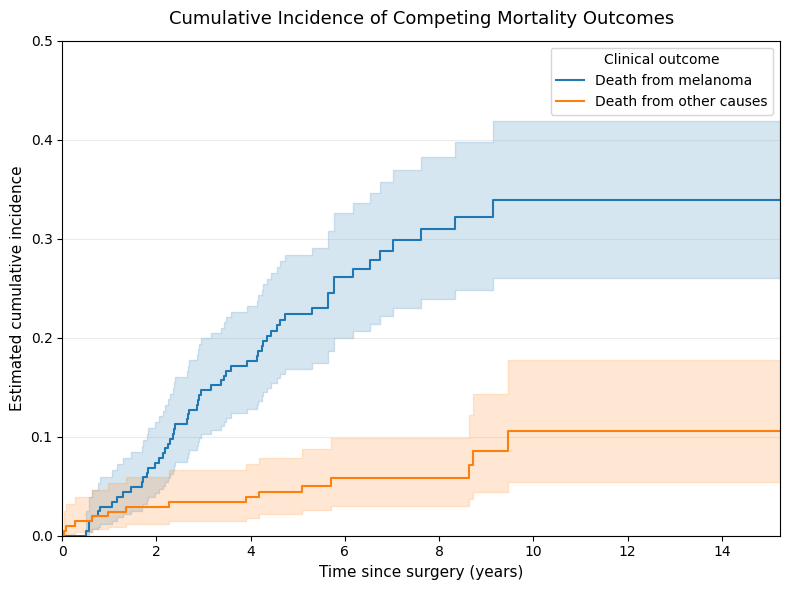

Saved files:
outputs/competing_risk_overall_cumulative_incidence_curves.png
outputs/competing_risk_overall_cumulative_incidence_curves.csv


In [22]:
# Create publication-style overall cumulative-incidence curves
# for the two competing mortality pathways

# Combine the event times from both fitted Aalen–Johansen estimators
common_cif_timeline = np.union1d(
    aj_melanoma_overall.cumulative_density_.index.to_numpy(),
    aj_other_overall.cumulative_density_.index.to_numpy(),
)

# Helper function: align a fitted cumulative-incidence curve
# to the shared event-time grid using its step-function structure
def align_cif_curve(fitted_estimator, timeline):
    cif_series = fitted_estimator.cumulative_density_.iloc[:, 0]

    return (
        cif_series
        .reindex(
            cif_series.index.union(
                pd.Index(timeline)
            )
        )
        .sort_index()
        .ffill()
        .fillna(0.0)
        .reindex(timeline)
        .to_numpy()
    )

# Create a repository-ready full curve table
overall_cif_curves = pd.DataFrame(
    {
        "time_years": common_cif_timeline,
        "melanoma_death_cumulative_incidence": (
            align_cif_curve(
                aj_melanoma_overall,
                common_cif_timeline,
            )
        ),
        "other_cause_death_cumulative_incidence": (
            align_cif_curve(
                aj_other_overall,
                common_cif_timeline,
            )
        ),
    }
)

overall_cif_curves["event_free_probability"] = (
    1
    - overall_cif_curves[
        "melanoma_death_cumulative_incidence"
    ]
    - overall_cif_curves[
        "other_cause_death_cumulative_incidence"
    ]
)

# Determine a readable vertical scale while preserving valid probability limits
maximum_cif = overall_cif_curves[
    [
        "melanoma_death_cumulative_incidence",
        "other_cause_death_cumulative_incidence",
    ]
].to_numpy().max()

upper_y_limit = 0.50

# Create the figure
fig, ax = plt.subplots(figsize=(8, 6))

aj_melanoma_overall.plot_cumulative_density(
    ax=ax,
    ci_show=True,
    ci_alpha=0.18,
)

aj_other_overall.plot_cumulative_density(
    ax=ax,
    ci_show=True,
    ci_alpha=0.18,
)

ax.set_title(
    "Cumulative Incidence of Competing Mortality Outcomes",
    fontsize=13,
    pad=12,
)

ax.set_xlabel(
    "Time since surgery (years)",
    fontsize=11,
)

ax.set_ylabel(
    "Estimated cumulative incidence",
    fontsize=11,
)

ax.set_xlim(
    0,
    melanoma["time_years"].max(),
)

ax.set_ylim(
    0,
    upper_y_limit,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    title="Clinical outcome",
)

plt.tight_layout()

# Save repository-ready outputs
figure_path = (
    outputs_dir
    / "competing_risk_overall_cumulative_incidence_curves.png"
)

curve_table_path = (
    outputs_dir
    / "competing_risk_overall_cumulative_incidence_curves.csv"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

overall_cif_curves.to_csv(
    curve_table_path,
    index=False,
)

plt.show()

print("Saved files:")
print(figure_path)
print(curve_table_path)

### Overall Competing-Risk Findings

The Aalen–Johansen cumulative-incidence curves showed that melanoma-related death was the dominant mortality pathway during follow-up.

At 5 years after surgery, the estimated cumulative incidence was:

* `22.4%` for death from melanoma,
* `4.4%` for death from other causes.

At 10 years, the corresponding cumulative-incidence estimates were:

* `33.9%` for death from melanoma,
* `10.6%` for death from other causes.

The estimated event-free probabilities were:

* `73.2%` at 5 years,
* `55.5%` at 10 years.

These event-free estimates are consistent with the overall Kaplan–Meier all-cause survival estimates because remaining event-free in the competing-risk framework corresponds to remaining alive without either mortality event.

### Interpretation Boundary

The cumulative-incidence curves estimate the observed probability of each mortality pathway over time while respecting the fact that the two outcomes are mutually exclusive.

The melanoma-related cumulative-incidence curve should not be interpreted as a cause-specific hazard curve. It represents the probability of melanoma-related death in the presence of competing deaths from other causes.

The next analysis will examine whether the cumulative incidence of melanoma-related death differs according to tumour ulceration status.


---

## 13. Melanoma-Related Cumulative Incidence by Tumour Ulceration Status

The overall competing-risk analysis showed that melanoma-related death was the dominant mortality pathway. The next step is to examine whether the estimated probability of melanoma-related death differs according to tumour ulceration status.

### Stratified Cumulative-Incidence Curves

Separate Aalen–Johansen cumulative-incidence functions will be estimated for:

* patients without tumour ulceration,
* patients with tumour ulceration.

The event of interest remains melanoma-related death. Death from another cause will remain a competing event rather than being treated as ordinary censoring.

### Clinical Interpretation

The resulting curves will describe the estimated probability of melanoma-related death over time within each ulceration group while accounting appropriately for other-cause mortality.

A higher cumulative-incidence curve in the ulceration-present group would indicate that melanoma-related death was observed more frequently over follow-up among patients with ulcerated tumours.

### Important Distinction

This analysis differs from the earlier Kaplan–Meier comparison:

* the Kaplan–Meier curves described all-cause survival,
* the cumulative-incidence curves describe the probability of melanoma-related death in the presence of competing mortality.

The cumulative-incidence curves also differ from the Cox hazard-ratio estimates:

* cumulative incidence summarizes the observed probability of the event over time,
* a cause-specific Cox model evaluates the instantaneous melanoma-death hazard among patients who remain alive and event-free.

### Interpretation Boundary

The stratified curves will provide an unadjusted descriptive comparison. Any observed separation should not be interpreted as an independent or causal effect of ulceration because the groups may also differ in age, sex, tumour thickness, and other prognostic characteristics.

A focused cause-specific Cox model will follow later to provide an adjusted complementary analysis.


In [23]:
# Estimate melanoma-related cumulative-incidence functions
# separately for tumour ulceration absent versus present

aj_melanoma_ulcer_absent = AalenJohansenFitter(seed=42)
aj_melanoma_ulcer_present = AalenJohansenFitter(seed=42)

# Event of interest = 1: death from melanoma
aj_melanoma_ulcer_absent.fit(
    durations=ulcer_absent["time_years"],
    event_observed=ulcer_absent["competing_event"],
    event_of_interest=1,
    label="Ulceration absent",
)

aj_melanoma_ulcer_present.fit(
    durations=ulcer_present["time_years"],
    event_observed=ulcer_present["competing_event"],
    event_of_interest=1,
    label="Ulceration present",
)

selected_times = [1.0, 3.0, 5.0, 10.0]

# Create a concise clinical summary table
melanoma_cif_by_ulceration_summary = pd.DataFrame(
    {
        "time_years": selected_times,
        "ulceration_absent_melanoma_death_cumulative_incidence": (
            extract_step_function_values(
                aj_melanoma_ulcer_absent,
                selected_times,
            )
        ),
        "ulceration_present_melanoma_death_cumulative_incidence": (
            extract_step_function_values(
                aj_melanoma_ulcer_present,
                selected_times,
            )
        ),
    }
)

# Add readable percentage columns
melanoma_cif_by_ulceration_summary[
    "ulceration_absent_melanoma_death_percent"
] = (
    100
    * melanoma_cif_by_ulceration_summary[
        "ulceration_absent_melanoma_death_cumulative_incidence"
    ]
).round(1)

melanoma_cif_by_ulceration_summary[
    "ulceration_present_melanoma_death_percent"
] = (
    100
    * melanoma_cif_by_ulceration_summary[
        "ulceration_present_melanoma_death_cumulative_incidence"
    ]
).round(1)

melanoma_cif_by_ulceration_summary[
    "absolute_difference_percentage_points"
] = (
    melanoma_cif_by_ulceration_summary[
        "ulceration_present_melanoma_death_percent"
    ]
    - melanoma_cif_by_ulceration_summary[
        "ulceration_absent_melanoma_death_percent"
    ]
).round(1)

# Create a descriptive event-count table for the two groups
ulceration_competing_risk_counts = pd.DataFrame(
    {
        "ulceration_status": [
            "Absent",
            "Present",
        ],
        "patients_n": [
            len(ulcer_absent),
            len(ulcer_present),
        ],
        "melanoma_deaths_n": [
            int((ulcer_absent["competing_event"] == 1).sum()),
            int((ulcer_present["competing_event"] == 1).sum()),
        ],
        "other_cause_deaths_n": [
            int((ulcer_absent["competing_event"] == 2).sum()),
            int((ulcer_present["competing_event"] == 2).sum()),
        ],
        "alive_censored_n": [
            int((ulcer_absent["competing_event"] == 0).sum()),
            int((ulcer_present["competing_event"] == 0).sum()),
        ],
    }
)

# Verify that estimated cumulative incidences remain valid
assert (
    melanoma_cif_by_ulceration_summary[
        [
            "ulceration_absent_melanoma_death_cumulative_incidence",
            "ulceration_present_melanoma_death_cumulative_incidence",
        ]
    ]
    .ge(0)
    .all()
    .all()
)

assert (
    melanoma_cif_by_ulceration_summary[
        [
            "ulceration_absent_melanoma_death_cumulative_incidence",
            "ulceration_present_melanoma_death_cumulative_incidence",
        ]
    ]
    .le(1)
    .all()
    .all()
)

# Save repository-ready CSV tables
summary_path = (
    outputs_dir
    / "competing_risk_melanoma_cif_by_ulceration_summary.csv"
)

counts_path = (
    outputs_dir
    / "competing_risk_event_counts_by_ulceration.csv"
)

melanoma_cif_by_ulceration_summary.to_csv(
    summary_path,
    index=False,
)

ulceration_competing_risk_counts.to_csv(
    counts_path,
    index=False,
)

print("MELANOMA-RELATED CUMULATIVE INCIDENCE BY ULCERATION STATUS")
display(melanoma_cif_by_ulceration_summary)

print("\nCOMPETING-RISK EVENT COUNTS BY ULCERATION STATUS")
display(ulceration_competing_risk_counts)

print("\nSaved files:")
print(summary_path)
print(counts_path)

MELANOMA-RELATED CUMULATIVE INCIDENCE BY ULCERATION STATUS


/usr/local/lib/python3.12/dist-packages/lifelines/fitters/aalen_johansen_fitter.py:112: Warning: Tied event times were detected. The Aalen-Johansen estimator cannot handle tied event times.
                To resolve ties, data is randomly jittered.
  warnings.warn(


,time_years,ulceration_absent_melanoma_death_cumulative_incidence,ulceration_present_melanoma_death_cumulative_incidence,ulceration_absent_melanoma_death_percent,ulceration_present_melanoma_death_percent,absolute_difference_percentage_points
0,1.000,0.000,0.067,0.000,6.700,6.700
1,3.000,0.044,0.278,4.400,27.800,23.400
2,5.000,0.091,0.390,9.100,39.000,29.900
3,10.000,0.182,0.533,18.200,53.300,35.100



COMPETING-RISK EVENT COUNTS BY ULCERATION STATUS


,ulceration_status,patients_n,melanoma_deaths_n,other_cause_deaths_n,alive_censored_n
0,Absent,115,16,7,92
1,Present,90,41,7,42



Saved files:
outputs/competing_risk_melanoma_cif_by_ulceration_summary.csv
outputs/competing_risk_event_counts_by_ulceration.csv


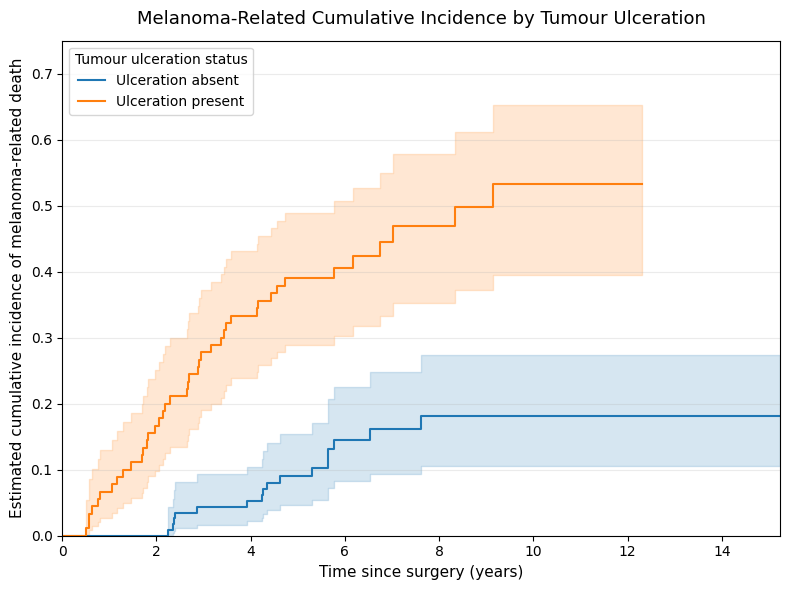

Saved files:
outputs/competing_risk_melanoma_cif_by_ulceration.png
outputs/competing_risk_melanoma_cif_by_ulceration_curves.csv


In [24]:
# Create publication-style melanoma-related cumulative-incidence curves
# by tumour ulceration status

# Combine event times from both fitted Aalen–Johansen estimators
common_ulceration_cif_timeline = np.union1d(
    aj_melanoma_ulcer_absent.cumulative_density_.index.to_numpy(),
    aj_melanoma_ulcer_present.cumulative_density_.index.to_numpy(),
)

# Create a repository-ready full curve table
melanoma_cif_by_ulceration_curves = pd.DataFrame(
    {
        "time_years": common_ulceration_cif_timeline,
        "ulceration_absent_melanoma_death_cumulative_incidence": (
            align_cif_curve(
                aj_melanoma_ulcer_absent,
                common_ulceration_cif_timeline,
            )
        ),
        "ulceration_present_melanoma_death_cumulative_incidence": (
            align_cif_curve(
                aj_melanoma_ulcer_present,
                common_ulceration_cif_timeline,
            )
        ),
    }
)

# Create the publication-style figure
fig, ax = plt.subplots(figsize=(8, 6))

aj_melanoma_ulcer_absent.plot_cumulative_density(
    ax=ax,
    ci_show=True,
    ci_alpha=0.18,
)

aj_melanoma_ulcer_present.plot_cumulative_density(
    ax=ax,
    ci_show=True,
    ci_alpha=0.18,
)

ax.set_title(
    "Melanoma-Related Cumulative Incidence by Tumour Ulceration",
    fontsize=13,
    pad=12,
)

ax.set_xlabel(
    "Time since surgery (years)",
    fontsize=11,
)

ax.set_ylabel(
    "Estimated cumulative incidence of melanoma-related death",
    fontsize=11,
)

ax.set_xlim(
    0,
    melanoma["time_years"].max(),
)

ax.set_ylim(
    0,
    0.75,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    title="Tumour ulceration status",
)

plt.tight_layout()

# Save repository-ready outputs
figure_path = (
    outputs_dir
    / "competing_risk_melanoma_cif_by_ulceration.png"
)

curve_table_path = (
    outputs_dir
    / "competing_risk_melanoma_cif_by_ulceration_curves.csv"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

melanoma_cif_by_ulceration_curves.to_csv(
    curve_table_path,
    index=False,
)

plt.show()

print("Saved files:")
print(figure_path)
print(curve_table_path)

### Melanoma-Related Cumulative-Incidence Findings by Ulceration Status

The Aalen–Johansen curves showed a substantial unadjusted difference in the estimated probability of melanoma-related death according to tumour ulceration status.

At 5 years after surgery, the estimated cumulative incidence of melanoma-related death was:

* `9.1%` among patients without tumour ulceration,
* `39.0%` among patients with tumour ulceration.

This corresponds to an absolute difference of `29.9` percentage points.

At 10 years, the corresponding cumulative-incidence estimates were:

* `18.2%` among patients without tumour ulceration,
* `53.3%` among patients with tumour ulceration.

The absolute difference widened to `35.1` percentage points.

### Clinical Interpretation

Tumour ulceration was associated with a markedly higher observed probability of melanoma-related death over follow-up.

This pattern is clinically consistent with the earlier all-cause Kaplan–Meier comparison and the adjusted primary Cox-model findings. However, the cumulative-incidence curves answer a different question: they describe the observed probability of melanoma-related mortality in the presence of competing deaths from other causes.

### Interpretation Boundary

The stratified cumulative-incidence curves are unadjusted descriptive estimates. They should not be interpreted as causal effects or as independent associations because the ulceration groups also differ in other prognostic characteristics, including tumour thickness, age, and sex composition.

A cause-specific Cox model will now be fitted to evaluate adjusted associations with the instantaneous hazard of melanoma-related death among patients who remain alive and event-free.


---

## 14. Cause-Specific Cox Modeling for Melanoma-Related Death

The cumulative-incidence curves describe the observed probability of melanoma-related death over time while accounting for competing deaths from other causes. A complementary cause-specific Cox model will now evaluate adjusted prognostic associations with the instantaneous hazard of melanoma-related mortality.

### Cause-Specific Outcome Definition

For this analysis:

* `melanoma_death_event = 1` for death from melanoma,
* `melanoma_death_event = 0` for patients alive at the end of follow-up,
* `melanoma_death_event = 0` for patients who died from another cause.

Patients who die from another cause are censored at the time of that competing event because they are no longer part of the risk set for melanoma-related death after that point.

### Adjusted Predictor Set

To preserve comparability with the primary all-cause Cox model, the cause-specific model will include the same focused predictors:

* age per 10-year increase,
* male sex versus female sex,
* year of surgery per 1-year increase,
* tumour thickness per doubling,
* and tumour ulceration present versus absent.

### Cause-Specific Hazard-Ratio Interpretation

A cause-specific hazard ratio estimates the relative instantaneous rate of melanoma-related death among patients who remain alive and event-free at a given time.

For example, a cause-specific hazard ratio above `1` for tumour ulceration would indicate that patients with ulcerated tumours experience a higher instantaneous melanoma-death hazard among those who are still alive and have not already experienced another mortality event.

### Important Distinction From Cumulative Incidence

The cause-specific hazard and the cumulative-incidence function answer related but different clinical questions:

* the **cause-specific hazard** evaluates the instantaneous rate of melanoma-related death among patients who remain event-free,
* the **cumulative-incidence function** evaluates the observed probability of melanoma-related death over time in the presence of competing mortality.

A cause-specific hazard ratio should not be interpreted as an adjusted cumulative-incidence ratio or as an absolute-risk difference.

### Modeling Boundary

This model estimates adjusted prognostic associations rather than causal effects. Proportional-hazards diagnostics will be reviewed separately for the melanoma-specific outcome before the findings are interpreted.


In [25]:
# Prepare the cause-specific Cox modeling dataset
# for melanoma-related mortality

cause_specific_df = melanoma[
    [
        "time_years",
        "competing_event",
        "age",
        "sex",
        "year",
        "thickness",
        "ulcer",
    ]
].copy()

# Define the cause-specific event:
# 1 = death from melanoma
# 0 = alive at end of follow-up or death from another cause
cause_specific_df["melanoma_death_event"] = (
    cause_specific_df["competing_event"] == 1
).astype(int)

# Create clinically interpretable transformations
cause_specific_df["age_per_10_years"] = (
    cause_specific_df["age"] / 10
)

cause_specific_df["male_sex"] = (
    cause_specific_df["sex"].astype(int)
)

cause_specific_df["surgery_year_centered"] = (
    cause_specific_df["year"]
    - cause_specific_df["year"].mean()
)

cause_specific_df["log2_tumour_thickness"] = (
    np.log2(cause_specific_df["thickness"])
)

cause_specific_df["ulceration_present"] = (
    cause_specific_df["ulcer"].astype(int)
)

# Retain only the variables needed for cause-specific Cox modeling
cause_specific_model_df = cause_specific_df[
    [
        "time_years",
        "melanoma_death_event",
        "age_per_10_years",
        "male_sex",
        "surgery_year_centered",
        "log2_tumour_thickness",
        "ulceration_present",
    ]
].copy()

# Verify data integrity
assert cause_specific_model_df.isna().sum().sum() == 0
assert np.isfinite(cause_specific_model_df).all().all()
assert cause_specific_model_df["time_years"].gt(0).all()
assert (
    int(cause_specific_model_df["melanoma_death_event"].sum())
    == int((melanoma["competing_event"] == 1).sum())
)

# Create an outcome-coding audit table
cause_specific_outcome_audit = pd.DataFrame(
    {
        "followup_outcome": [
            "Death from melanoma: event",
            "Death from other causes: censored at competing event",
            "Alive at end of follow-up: censored",
        ],
        "cause_specific_event_code": [
            1,
            0,
            0,
        ],
        "patients_n": [
            int((melanoma["competing_event"] == 1).sum()),
            int((melanoma["competing_event"] == 2).sum()),
            int((melanoma["competing_event"] == 0).sum()),
        ],
    }
)

# Save repository-ready CSV files
cause_specific_model_df.to_csv(
    outputs_dir / "cause_specific_melanoma_cox_model_dataset.csv",
    index=False,
)

cause_specific_outcome_audit.to_csv(
    outputs_dir / "cause_specific_melanoma_outcome_coding_audit.csv",
    index=False,
)

print("CAUSE-SPECIFIC COX MODELING DATASET PREPARED SUCCESSFULLY")
print(f"Patients included: {cause_specific_model_df.shape[0]}")
print(
    "Observed melanoma-related deaths: "
    f"{int(cause_specific_model_df['melanoma_death_event'].sum())}"
)
print(
    "Predictors included: "
    f"{cause_specific_model_df.shape[1] - 2}"
)

print("\nCAUSE-SPECIFIC OUTCOME-CODING AUDIT")
display(cause_specific_outcome_audit)

print("\nFIRST FIVE ROWS")
display(cause_specific_model_df.head())

print("\nSaved files:")
print(outputs_dir / "cause_specific_melanoma_cox_model_dataset.csv")
print(outputs_dir / "cause_specific_melanoma_outcome_coding_audit.csv")

CAUSE-SPECIFIC COX MODELING DATASET PREPARED SUCCESSFULLY
Patients included: 205
Observed melanoma-related deaths: 57
Predictors included: 5

CAUSE-SPECIFIC OUTCOME-CODING AUDIT


,followup_outcome,cause_specific_event_code,patients_n
0,Death from melanoma: event,1,57
1,Death from other causes: censored at competing...,0,14
2,Alive at end of follow-up: censored,0,134



FIRST FIVE ROWS


,time_years,melanoma_death_event,age_per_10_years,male_sex,surgery_year_centered,log2_tumour_thickness,ulceration_present
0,0.027,0,7.600,1,2.093,2.757,1
1,0.082,0,5.600,1,-1.907,-0.621,0
2,0.096,0,4.100,1,7.093,0.422,0
3,0.271,0,7.100,0,-1.907,1.536,0
4,0.507,1,5.200,1,-4.907,3.595,1



Saved files:
outputs/cause_specific_melanoma_cox_model_dataset.csv
outputs/cause_specific_melanoma_outcome_coding_audit.csv


In [26]:
# Fit the cause-specific Cox proportional-hazards model
# for melanoma-related death

cause_specific_cox = CoxPHFitter()

cause_specific_cox.fit(
    cause_specific_model_df,
    duration_col="time_years",
    event_col="melanoma_death_event",
    show_progress=False,
)

# Create readable clinical labels
cause_specific_covariate_labels = {
    "age_per_10_years": "Age: per 10-year increase",
    "male_sex": "Male sex: versus female",
    "surgery_year_centered": "Year of surgery: per 1-year increase",
    "log2_tumour_thickness": "Tumour thickness: per doubling",
    "ulceration_present": "Tumour ulceration: present versus absent",
}

# Extract a publication-ready cause-specific hazard-ratio table
cause_specific_hr_summary = (
    cause_specific_cox.summary[
        [
            "exp(coef)",
            "exp(coef) lower 95%",
            "exp(coef) upper 95%",
            "p",
        ]
    ]
    .rename(
        columns={
            "exp(coef)": "cause_specific_hazard_ratio",
            "exp(coef) lower 95%": "ci_95_lower",
            "exp(coef) upper 95%": "ci_95_upper",
            "p": "p_value",
        }
    )
    .reset_index()
    .rename(columns={"covariate": "variable"})
)

cause_specific_hr_summary["clinical_interpretation"] = (
    cause_specific_hr_summary["variable"]
    .map(cause_specific_covariate_labels)
)

cause_specific_hr_summary = cause_specific_hr_summary[
    [
        "variable",
        "clinical_interpretation",
        "cause_specific_hazard_ratio",
        "ci_95_lower",
        "ci_95_upper",
        "p_value",
    ]
]

# Save the repository-ready summary table
summary_path = (
    outputs_dir
    / "cause_specific_melanoma_cox_hazard_ratio_summary.csv"
)

cause_specific_hr_summary.to_csv(
    summary_path,
    index=False,
)

print("CAUSE-SPECIFIC COX MODEL: MELANOMA-RELATED DEATH")
print(f"Patients included: {cause_specific_cox._n_examples}")
print(
    "Observed melanoma-related deaths: "
    f"{int(cause_specific_model_df['melanoma_death_event'].sum())}"
)
print(
    "Concordance index: "
    f"{cause_specific_cox.concordance_index_:.3f}"
)
print(
    "Partial AIC: "
    f"{cause_specific_cox.AIC_partial_:.3f}"
)

print("\nADJUSTED CAUSE-SPECIFIC HAZARD-RATIO SUMMARY")
display(cause_specific_hr_summary)

print("\nSaved file:")
print(summary_path)

CAUSE-SPECIFIC COX MODEL: MELANOMA-RELATED DEATH
Patients included: 205
Observed melanoma-related deaths: 57
Concordance index: 0.768
Partial AIC: 529.277

ADJUSTED CAUSE-SPECIFIC HAZARD-RATIO SUMMARY


,variable,clinical_interpretation,cause_specific_hazard_ratio,ci_95_lower,ci_95_upper,p_value
0,age_per_10_years,Age: per 10-year increase,1.172,0.991,1.386,0.063
1,male_sex,Male sex: versus female,1.478,0.871,2.509,0.148
2,surgery_year_centered,Year of surgery: per 1-year increase,0.909,0.807,1.023,0.113
3,log2_tumour_thickness,Tumour thickness: per doubling,1.428,1.119,1.823,0.004
4,ulceration_present,Tumour ulceration: present versus absent,2.700,1.435,5.082,0.002



Saved file:
outputs/cause_specific_melanoma_cox_hazard_ratio_summary.csv


### Cause-Specific Cox-Model Findings

The adjusted cause-specific Cox model identified tumour thickness and tumour ulceration as important prognostic factors for melanoma-related mortality.

Each doubling of tumour thickness was associated with an estimated `42.8%` higher instantaneous hazard of melanoma-related death among patients who remained alive and event-free (`cause-specific HR = 1.43`, `95% CI: 1.12–1.82`, `p = 0.004`).

The presence of tumour ulceration was associated with an estimated `2.70`-fold higher instantaneous hazard of melanoma-related death (`95% CI: 1.44–5.08`, `p = 0.002`) after adjustment for age, sex, year of surgery, and tumour thickness.

Age showed a weaker association with melanoma-related mortality (`cause-specific HR = 1.17` per 10-year increase, `95% CI: 0.99–1.39`, `p = 0.063`). The confidence interval included `1`, so this estimate should be interpreted cautiously.

The evidence was not sufficiently strong to conclude that sex or year of surgery was independently associated with the cause-specific melanoma-death hazard in this model.

### Relationship to the Cumulative-Incidence Findings

The cause-specific Cox findings are directionally consistent with the earlier Aalen–Johansen cumulative-incidence curves, which showed a higher observed probability of melanoma-related death among patients with tumour ulceration.

However, the methods answer different questions:

* the cumulative-incidence function estimates the probability of melanoma-related death over time in the presence of competing mortality,
* the cause-specific hazard ratio estimates the relative instantaneous melanoma-death rate among patients who remain alive and event-free.

The cause-specific hazard ratio should not be interpreted as a cumulative-incidence ratio or as an absolute-risk difference.

### Diagnostic Plan

Before the cause-specific hazard-ratio estimates are interpreted as final model findings, the proportional-hazards assumption will be evaluated using Schoenfeld-residual-based tests.

The same cautious diagnostic principle used for the primary all-cause Cox model will be applied:

* numerical tests will be reviewed for each predictor,
* potentially concerning patterns will be interpreted in context,
* and the model will not be modified mechanically without a clear statistical and clinical reason.


In [27]:
# Run Schoenfeld-residual-based proportional-hazards diagnostics
# for the cause-specific melanoma-death Cox model

cause_specific_ph_test = proportional_hazard_test(
    fitted_cox_model=cause_specific_cox,
    training_df=cause_specific_model_df,
    time_transform=["rank", "km"],
)

# Convert the lifelines output into a clean repository-ready table
cause_specific_ph_test_summary = (
    cause_specific_ph_test.summary
    .reset_index()
    .rename(
        columns={
            "level_0": "variable",
            "level_1": "time_transform",
            "p": "p_value",
            "-log2(p)": "negative_log2_p_value",
        }
    )
)

# Flag results below the conventional diagnostic threshold
cause_specific_ph_test_summary["flag_p_lt_0_05"] = (
    cause_specific_ph_test_summary["p_value"] < 0.05
)

# Create a compact variable-level screening summary
cause_specific_ph_variable_screening = (
    cause_specific_ph_test_summary
    .groupby("variable", as_index=False)
    .agg(
        minimum_p_value=("p_value", "min"),
        flagged_by_any_test=("flag_p_lt_0_05", "any"),
    )
)

# Save repository-ready CSV tables
cause_specific_ph_test_summary.to_csv(
    outputs_dir / "cause_specific_melanoma_cox_ph_test_details.csv",
    index=False,
)

cause_specific_ph_variable_screening.to_csv(
    outputs_dir / "cause_specific_melanoma_cox_ph_screening_summary.csv",
    index=False,
)

print("CAUSE-SPECIFIC MELANOMA-DEATH PROPORTIONAL-HAZARDS TESTS")
display(cause_specific_ph_test_summary)

print("\nVARIABLE-LEVEL SCREENING SUMMARY")
display(cause_specific_ph_variable_screening)

print("\nSaved files:")
print(outputs_dir / "cause_specific_melanoma_cox_ph_test_details.csv")
print(outputs_dir / "cause_specific_melanoma_cox_ph_screening_summary.csv")

CAUSE-SPECIFIC MELANOMA-DEATH PROPORTIONAL-HAZARDS TESTS


,variable,time_transform,test_statistic,p_value,negative_log2_p_value,flag_p_lt_0_05
0,age_per_10_years,km,2.218,0.136,2.874,False
1,age_per_10_years,rank,2.049,0.152,2.714,False
2,log2_tumour_thickness,km,3.355,0.067,3.900,False
3,log2_tumour_thickness,rank,3.326,0.068,3.874,False
4,male_sex,km,0.706,0.401,1.320,False
5,male_sex,rank,0.731,0.393,1.348,False
6,surgery_year_centered,km,0.232,0.630,0.666,False
7,surgery_year_centered,rank,0.318,0.573,0.803,False
8,ulceration_present,km,0.826,0.363,1.460,False
9,ulceration_present,rank,1.229,0.268,1.901,False



VARIABLE-LEVEL SCREENING SUMMARY


,variable,minimum_p_value,flagged_by_any_test
0,age_per_10_years,0.136,False
1,log2_tumour_thickness,0.067,False
2,male_sex,0.393,False
3,surgery_year_centered,0.573,False
4,ulceration_present,0.268,False



Saved files:
outputs/cause_specific_melanoma_cox_ph_test_details.csv
outputs/cause_specific_melanoma_cox_ph_screening_summary.csv


### Cause-Specific Proportional-Hazards Diagnostic Findings

Schoenfeld-residual-based proportional-hazards tests were evaluated for the melanoma-specific Cox model using both rank-based and Kaplan–Meier-based transformations of follow-up time.

None of the selected covariates produced a diagnostic p-value below `0.05` under either transformation. The formal screening therefore did not identify clear evidence of a proportional-hazards violation for:

* age,
* sex,
* year of surgery,
* tumour thickness,
* or tumour ulceration status.

Tumour thickness produced the smallest diagnostic p-value (`p = 0.067`). This value remains above the conventional diagnostic threshold, but it is sufficiently close to warrant cautious interpretation rather than a mechanical claim that the proportional-hazards assumption is perfectly satisfied.

### Diagnostic Conclusion

The numerical diagnostics do not provide strong evidence that the cause-specific Cox model is invalid. The model will therefore be retained as the adjusted complementary analysis for melanoma-related mortality.

The hazard-ratio estimates should still be interpreted as parsimonious prognostic summaries. A non-significant diagnostic result does not prove that each association remains exactly constant over time, particularly in a modest clinical dataset with 57 melanoma-related deaths.

### Interpretation Boundary

The cause-specific model complements the cumulative-incidence analysis but does not replace it.

* The cause-specific Cox model summarizes adjusted associations with the instantaneous hazard of melanoma-related death among patients who remain alive and event-free.
* The Aalen–Johansen curves summarize the observed probability of melanoma-related death over time in the presence of competing mortality.

Both perspectives are required for a clinically responsible interpretation.


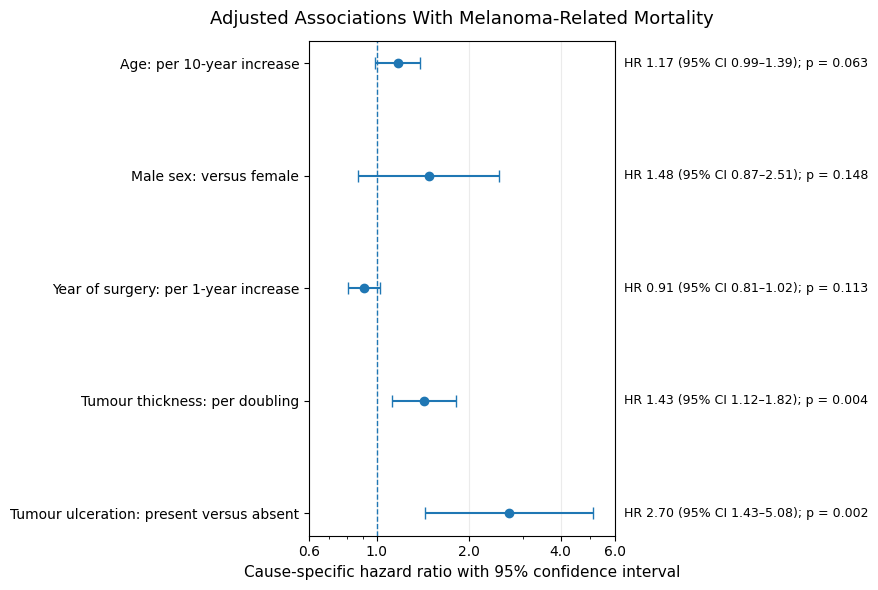

Saved figure:
outputs/cause_specific_melanoma_cox_hazard_ratio_forest_plot.png


In [28]:
# Create a publication-style forest plot for the cause-specific Cox model

from matplotlib.ticker import NullFormatter

# Preserve a clinically intuitive display order
cause_specific_forest_df = cause_specific_hr_summary.copy()

cause_specific_forest_df["display_label"] = (
    cause_specific_forest_df["clinical_interpretation"]
)

# Reverse the order so the first model term appears at the top
cause_specific_forest_df = (
    cause_specific_forest_df
    .iloc[::-1]
    .reset_index(drop=True)
)

# Calculate asymmetric confidence-interval distances
lower_error = (
    cause_specific_forest_df["cause_specific_hazard_ratio"]
    - cause_specific_forest_df["ci_95_lower"]
)

upper_error = (
    cause_specific_forest_df["ci_95_upper"]
    - cause_specific_forest_df["cause_specific_hazard_ratio"]
)

# Format p-values clearly
def format_cause_specific_p_value(p_value):
    if p_value < 0.001:
        return "p < 0.001"
    return f"p = {p_value:.3f}"

# Create the figure
fig, ax = plt.subplots(figsize=(9, 6))

y_positions = np.arange(len(cause_specific_forest_df))

ax.errorbar(
    x=cause_specific_forest_df["cause_specific_hazard_ratio"],
    y=y_positions,
    xerr=[lower_error, upper_error],
    fmt="o",
    markersize=6,
    capsize=4,
    linewidth=1.5,
)

# Add the null-reference line
ax.axvline(
    x=1,
    linestyle="--",
    linewidth=1,
)

# Add readable axis labels
ax.set_yticks(y_positions)

ax.set_yticklabels(
    cause_specific_forest_df["display_label"],
    fontsize=10,
)

ax.set_xscale("log")
ax.set_xlim(0.6, 6.0)

ax.set_xticks([0.6, 1.0, 2.0, 4.0, 6.0])
ax.set_xticklabels(["0.6", "1.0", "2.0", "4.0", "6.0"])
ax.xaxis.set_minor_formatter(NullFormatter())

ax.set_xlabel(
    "Cause-specific hazard ratio with 95% confidence interval",
    fontsize=11,
)

ax.set_title(
    "Adjusted Associations With Melanoma-Related Mortality",
    fontsize=13,
    pad=12,
)

ax.grid(
    axis="x",
    alpha=0.25,
)

# Add numerical summaries to the right of the figure
for y_position, row in cause_specific_forest_df.iterrows():

    annotation = (
        f"HR {row['cause_specific_hazard_ratio']:.2f} "
        f"(95% CI {row['ci_95_lower']:.2f}–{row['ci_95_upper']:.2f}); "
        f"{format_cause_specific_p_value(row['p_value'])}"
    )

    ax.text(
        1.03,
        y_position,
        annotation,
        transform=ax.get_yaxis_transform(),
        va="center",
        fontsize=9,
    )

plt.tight_layout()

# Save a repository-ready high-resolution PNG figure
figure_path = (
    outputs_dir
    / "cause_specific_melanoma_cox_hazard_ratio_forest_plot.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(figure_path)

---

## 15. Robustness Check: Why Competing Deaths Should Not Be Treated as Ordinary Censoring

The primary competing-risk analysis used the Aalen–Johansen estimator to calculate the cumulative incidence of melanoma-related death while accounting appropriately for deaths from other causes.

A useful robustness and teaching comparison is to estimate melanoma-related mortality using a naïve Kaplan–Meier approach in which deaths from other causes are treated as ordinary censored observations.

### Why the Naïve Approach Can Be Misleading

When another-cause death occurs, the patient can no longer experience melanoma-related death. Treating that competing event as ordinary censoring incorrectly assumes that the patient could still experience the melanoma-related outcome later.

The naïve Kaplan–Meier approach therefore estimates a hypothetical quantity rather than the observed probability of melanoma-related death in the presence of competing mortality.

### Planned Comparison

The analysis will compare:

* the Aalen–Johansen cumulative-incidence function for melanoma-related death,
* the naïve Kaplan–Meier estimate of `1 − survival probability` when other-cause deaths are treated as censored.

The comparison will be summarized at clinically interpretable time points and displayed visually.

### Interpretation Principle

The Aalen–Johansen estimate will remain the clinically appropriate primary estimate for melanoma-related cumulative incidence.

The naïve Kaplan–Meier estimate is included only to demonstrate how ignoring competing mortality can lead to overestimation, particularly during longer follow-up periods when competing events accumulate.


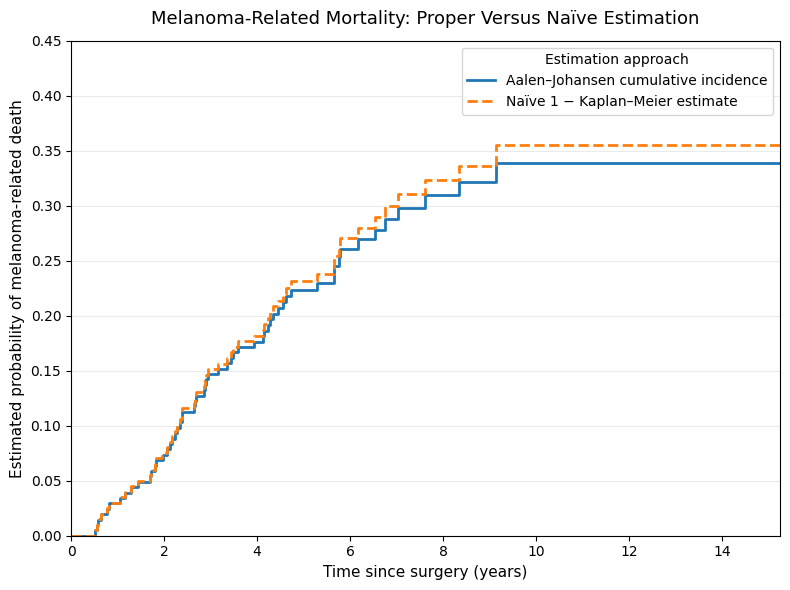

AALEN–JOHANSEN VERSUS NAÏVE 1 − KAPLAN–MEIER SUMMARY


,time_years,aalen_johansen_melanoma_death_cumulative_incidence,naive_one_minus_km_estimate,absolute_overestimation_percentage_points,aalen_johansen_percent,naive_one_minus_km_percent
0,1.000,0.029,0.030,0.000,2.900,3.000
1,3.000,0.147,0.151,0.400,14.700,15.100
2,5.000,0.224,0.231,0.800,22.400,23.100
3,10.000,0.339,0.355,1.600,33.900,35.500



Saved files:
outputs/competing_risk_aalen_johansen_vs_naive_km.png
outputs/competing_risk_aalen_johansen_vs_naive_km_curves.csv
outputs/competing_risk_aalen_johansen_vs_naive_km_summary.csv


In [29]:
# Robustness comparison:
# proper Aalen–Johansen cumulative incidence versus naïve 1 - Kaplan–Meier

# Fit a naïve Kaplan–Meier model for melanoma-related death
# Deaths from other causes are treated as ordinary censoring here
naive_melanoma_km = KaplanMeierFitter(
    label="Naïve 1 − Kaplan–Meier"
)

naive_melanoma_km.fit(
    durations=melanoma["time_years"],
    event_observed=(
        melanoma["competing_event"] == 1
    ).astype(int),
)

# Helper function: retrieve naïve 1 - KM estimates
# at selected follow-up times
def extract_naive_one_minus_km_values(fitted_km, times):
    survival_series = fitted_km.survival_function_.iloc[:, 0]

    expanded_index = survival_series.index.union(
        pd.Index(times, dtype=float)
    )

    aligned_survival = (
        survival_series
        .reindex(expanded_index)
        .sort_index()
        .ffill()
        .fillna(1.0)
        .loc[times]
        .to_numpy()
    )

    return 1 - aligned_survival


selected_times = [1.0, 3.0, 5.0, 10.0]

# Create a concise numerical comparison
naive_vs_aj_summary = pd.DataFrame(
    {
        "time_years": selected_times,
        "aalen_johansen_melanoma_death_cumulative_incidence": (
            extract_step_function_values(
                aj_melanoma_overall,
                selected_times,
            )
        ),
        "naive_one_minus_km_estimate": (
            extract_naive_one_minus_km_values(
                naive_melanoma_km,
                selected_times,
            )
        ),
    }
)

# Quantify the degree of overestimation
naive_vs_aj_summary[
    "absolute_overestimation_percentage_points"
] = (
    100
    * (
        naive_vs_aj_summary["naive_one_minus_km_estimate"]
        - naive_vs_aj_summary[
            "aalen_johansen_melanoma_death_cumulative_incidence"
        ]
    )
).round(1)

naive_vs_aj_summary[
    "aalen_johansen_percent"
] = (
    100
    * naive_vs_aj_summary[
        "aalen_johansen_melanoma_death_cumulative_incidence"
    ]
).round(1)

naive_vs_aj_summary[
    "naive_one_minus_km_percent"
] = (
    100
    * naive_vs_aj_summary[
        "naive_one_minus_km_estimate"
    ]
).round(1)

# Create a shared timeline for the complete curves
comparison_timeline = np.union1d(
    aj_melanoma_overall.cumulative_density_.index.to_numpy(),
    naive_melanoma_km.survival_function_.index.to_numpy(),
)

# Align the proper Aalen–Johansen estimate
aligned_aj_curve = align_cif_curve(
    aj_melanoma_overall,
    comparison_timeline,
)

# Align the naïve 1 - KM estimate
naive_survival_series = (
    naive_melanoma_km
    .survival_function_
    .iloc[:, 0]
)

aligned_naive_one_minus_km = (
    1
    - naive_survival_series
    .reindex(
        naive_survival_series.index.union(
            pd.Index(comparison_timeline)
        )
    )
    .sort_index()
    .ffill()
    .fillna(1.0)
    .reindex(comparison_timeline)
    .to_numpy()
)

# Create a repository-ready full curve table
naive_vs_aj_curves = pd.DataFrame(
    {
        "time_years": comparison_timeline,
        "aalen_johansen_melanoma_death_cumulative_incidence": (
            aligned_aj_curve
        ),
        "naive_one_minus_km_estimate": (
            aligned_naive_one_minus_km
        ),
    }
)

naive_vs_aj_curves[
    "absolute_overestimation"
] = (
    naive_vs_aj_curves["naive_one_minus_km_estimate"]
    - naive_vs_aj_curves[
        "aalen_johansen_melanoma_death_cumulative_incidence"
    ]
)

# Verify the expected direction at the prespecified clinical time points.
# A strict pointwise check across the complete merged timeline is avoided
# because Aalen–Johansen estimation applies small jitter adjustments
# when tied event times are present.

assert (
    naive_vs_aj_summary["naive_one_minus_km_estimate"]
    >= (
        naive_vs_aj_summary[
            "aalen_johansen_melanoma_death_cumulative_incidence"
        ]
        - 1e-10
    )
).all()

# Create the publication-style comparison figure
fig, ax = plt.subplots(figsize=(8, 6))

ax.step(
    naive_vs_aj_curves["time_years"],
    naive_vs_aj_curves[
        "aalen_johansen_melanoma_death_cumulative_incidence"
    ],
    where="post",
    linewidth=2,
    label="Aalen–Johansen cumulative incidence",
)

ax.step(
    naive_vs_aj_curves["time_years"],
    naive_vs_aj_curves["naive_one_minus_km_estimate"],
    where="post",
    linewidth=2,
    linestyle="--",
    label="Naïve 1 − Kaplan–Meier estimate",
)

ax.set_title(
    "Melanoma-Related Mortality: Proper Versus Naïve Estimation",
    fontsize=13,
    pad=12,
)

ax.set_xlabel(
    "Time since surgery (years)",
    fontsize=11,
)

ax.set_ylabel(
    "Estimated probability of melanoma-related death",
    fontsize=11,
)

ax.set_xlim(
    0,
    melanoma["time_years"].max(),
)

ax.set_ylim(
    0,
    0.45,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    title="Estimation approach",
)

plt.tight_layout()

# Save repository-ready outputs
figure_path = (
    outputs_dir
    / "competing_risk_aalen_johansen_vs_naive_km.png"
)

curve_table_path = (
    outputs_dir
    / "competing_risk_aalen_johansen_vs_naive_km_curves.csv"
)

summary_table_path = (
    outputs_dir
    / "competing_risk_aalen_johansen_vs_naive_km_summary.csv"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

naive_vs_aj_curves.to_csv(
    curve_table_path,
    index=False,
)

naive_vs_aj_summary.to_csv(
    summary_table_path,
    index=False,
)

plt.show()

print("AALEN–JOHANSEN VERSUS NAÏVE 1 − KAPLAN–MEIER SUMMARY")
display(naive_vs_aj_summary)

print("\nSaved files:")
print(figure_path)
print(curve_table_path)
print(summary_table_path)

### Aalen–Johansen Versus Naïve Kaplan–Meier Findings

The robustness comparison showed that treating deaths from other causes as ordinary censored observations produced slightly higher estimates of melanoma-related mortality than the Aalen–Johansen competing-risk estimator.

At 5 years after surgery:

- the Aalen–Johansen cumulative-incidence estimate was `22.4%`,
- the naïve `1 − Kaplan–Meier` estimate was `23.1%`,
- corresponding to an overestimation of `0.8` percentage points after rounding.

At 10 years:

- the Aalen–Johansen cumulative-incidence estimate was `33.9%`,
- the naïve `1 − Kaplan–Meier` estimate was `35.5%`,
- corresponding to an overestimation of `1.6` percentage points.

### Clinical and Methodological Interpretation

The degree of overestimation was modest in this cohort because deaths from other causes were relatively uncommon: only 14 competing deaths were observed.

Nevertheless, the difference increased over time as competing events accumulated. This illustrates an important principle: even when the numerical difference is small in a particular dataset, other-cause deaths should not be treated as ordinary censoring when the clinical objective is to estimate the observed probability of melanoma-related death.

The magnitude of the bias depends on the frequency and timing of competing events. In clinical settings with more frequent competing mortality, the difference between naïve Kaplan–Meier estimation and proper cumulative-incidence estimation may become substantially larger.

### Interpretation Boundary

The Aalen–Johansen estimator remains the clinically appropriate primary method for estimating melanoma-related cumulative incidence in the presence of competing deaths.

The naïve Kaplan–Meier estimate is included only as a methodological robustness and teaching comparison. It should not be used as the primary event-probability estimate.

---

## 16. Integrated Clinical Interpretation and Limitations

### Main Clinical Findings

This analysis examined survival outcomes after surgical treatment for malignant melanoma using a reproducible clinical time-to-event workflow.

The conventional all-cause survival analysis showed that patients with tumour ulceration experienced substantially poorer unadjusted survival than patients without ulceration. At 5 years after surgery, the Kaplan–Meier all-cause survival estimates were:

* `88.3%` among patients without tumour ulceration,
* `54.3%` among patients with tumour ulceration.

The log-rank comparison provided strong evidence that the unadjusted survival distributions differed (`p < 0.001`).

### Adjusted All-Cause Mortality Findings

In the primary multivariable Cox proportional-hazards model, several clinically meaningful prognostic associations remained evident after adjustment for the selected covariates.

* Each 10-year increase in age was associated with an estimated `28.0%` higher all-cause mortality hazard (`HR = 1.28`, `95% CI: 1.10–1.49`, `p = 0.002`).
* Each doubling of tumour thickness was associated with an estimated `32.0%` higher all-cause mortality hazard (`HR = 1.32`, `95% CI: 1.07–1.63`, `p = 0.011`).
* Tumour ulceration was associated with an estimated `2.32`-fold higher all-cause mortality hazard (`95% CI: 1.33–4.02`, `p = 0.003`).

The model showed useful prognostic discrimination (`concordance index = 0.740`).

Formal proportional-hazards tests did not identify clear violations. However, the visual residual diagnostics suggested possible attenuation of the ulceration association during later follow-up.

A focused exploratory sensitivity analysis supported cautious consideration of this pattern:

* during the first 5 years, the adjusted ulceration hazard ratio was `3.20` (`95% CI: 1.64–6.24`),
* beyond 5 years, the estimate was weaker and imprecise (`HR = 1.01`, `95% CI: 0.37–2.74`),
* and the interaction test was borderline (`p = 0.0502`).

Because only 17 all-cause deaths occurred after 5 years, this time-varying pattern should be treated as exploratory rather than definitive.

### Competing-Risk Findings

The competing-risk analysis separated melanoma-related mortality from deaths due to other causes.

At 5 years after surgery, the Aalen–Johansen cumulative-incidence estimates were:

* `22.4%` for melanoma-related death,
* `4.4%` for death from other causes.

At 10 years, the corresponding estimates were:

* `33.9%` for melanoma-related death,
* `10.6%` for death from other causes.

Melanoma-related death was therefore the dominant observed mortality pathway.

Tumour ulceration was associated with a pronounced unadjusted difference in melanoma-related cumulative incidence:

* at 5 years: `39.0%` with ulceration versus `9.1%` without ulceration,
* at 10 years: `53.3%` with ulceration versus `18.2%` without ulceration.

### Adjusted Melanoma-Specific Findings

The cause-specific Cox model provided a complementary adjusted interpretation for melanoma-related mortality.

* Each doubling of tumour thickness was associated with an estimated `42.8%` higher cause-specific melanoma-death hazard (`HR = 1.43`, `95% CI: 1.12–1.82`, `p = 0.004`).
* Tumour ulceration was associated with an estimated `2.70`-fold higher cause-specific melanoma-death hazard (`95% CI: 1.44–5.08`, `p = 0.002`).

The cause-specific model showed useful prognostic discrimination (`concordance index = 0.768`). Schoenfeld-residual-based tests did not identify a clear proportional-hazards violation.

### Why the Competing-Risk Framework Matters

The robustness comparison showed that treating other-cause deaths as ordinary censoring produced slightly higher melanoma-mortality estimates than the Aalen–Johansen method.

At 10 years:

* the proper Aalen–Johansen estimate was `33.9%`,
* the naïve `1 − Kaplan–Meier` estimate was `35.5%`.

The numerical difference was modest because only 14 competing deaths were observed. However, the comparison illustrates an important clinical principle: the probability of a specific event should be estimated using a competing-risk framework when mutually exclusive outcomes are present.

---

## Limitations

This project should be interpreted with several limitations in mind.

### Observational Prognostic Analysis

The dataset is observational. The estimated associations describe prognostic relationships and should not be interpreted as causal effects. Tumour ulceration and tumour thickness are clinical characteristics rather than interventions.

### Modest Sample Size and Event Counts

The cohort contains 205 patients, including:

* 71 all-cause deaths,
* 57 melanoma-related deaths,
* 14 deaths from other causes.

The multivariable models were intentionally parsimonious to reduce overfitting risk. Estimates involving later follow-up or other-cause mortality remain less precise because fewer events were observed.

### Limited Clinical Covariates

The available dataset does not include several potentially important prognostic factors, such as tumour stage, anatomical site, treatment details, comorbidity burden, or molecular biomarkers.

Residual confounding and incomplete prognostic adjustment are therefore possible.

### Model-Specification Constraints

The Cox model summarizes relative hazards under a proportional-hazards framework. Formal diagnostics were reassuring, but the exploratory analysis suggested that the ulceration association may weaken during later follow-up.

The standardized survival curves should therefore be interpreted as useful summaries of the primary fitted model rather than as definitive long-term predictions for individual patients.

### Competing-Risk Modeling Scope

The project used:

* Aalen–Johansen cumulative-incidence estimation,
* and cause-specific Cox modeling.

These methods provide clinically useful complementary perspectives. A subdistribution-hazard model was not fitted because the project emphasizes interpretable separation between event probability and cause-specific hazard rather than relying on a single competing-risk regression framework.

### External Validation

The findings were not externally validated in an independent clinical cohort. The analysis demonstrates a rigorous methodological workflow rather than a deployable clinical prediction model.

---

## Final Interpretation Boundary

The project demonstrates how conventional survival analysis and competing-risk methods answer related but distinct clinical questions.

* Kaplan–Meier analysis describes all-cause survival.
* The Cox proportional-hazards model summarizes adjusted prognostic associations with all-cause mortality.
* Aalen–Johansen estimation describes the probability of each competing mortality pathway.
* Cause-specific Cox modeling evaluates adjusted associations with the instantaneous melanoma-death hazard among patients who remain alive and event-free.

The results should be interpreted together rather than interchangeably.

The strongest consistent prognostic findings were associated with tumour ulceration and tumour thickness. These characteristics were linked to poorer all-cause survival and a higher melanoma-related mortality hazard, while competing-risk methods clarified how melanoma-related death accumulated over time in the presence of other-cause mortality.


---

## 17. Repository Output Audit and Final Export Preparation

The analytical workflow has produced a collection of repository-ready figures and tables. Before downloading the final notebook or creating the GitHub package, the saved outputs will be audited carefully.

### Audit Objectives

The output audit will verify:

* the total number of saved files,
* the names of all generated figures and tables,
* the file type of each output,
* the size of each saved file,
* and whether any unexpected temporary files are present.

### Repository Structure

The completed GitHub repository will use the following clean structure:

```text
survival-competing-risk-clinical-python
│
├── outputs
├── Survival_Competing_Risk_Clinical_Python.ipynb
└── README.md
```

The `outputs` folder will contain publication-style PNG figures and reproducible CSV tables generated during the analysis.

### Finalization Principle

The repository will be packaged only after confirming that:

* the notebook runs coherently from beginning to end,
* the analytical outputs are complete,
* the saved filenames are clear and consistent,
* and unnecessary temporary files have been removed.

The README file, ZIP package, and GitHub upload steps will be completed only after this audit.


In [30]:
# Audit all repository-ready outputs generated during the analysis

expected_outputs = {
    # Cohort preparation and censoring assessment
    "censoring_followup_summary.csv",
    "clinical_cohort_profile_by_ulceration.csv",

    # Kaplan–Meier survival analysis
    "km_overall_all_cause_survival.png",
    "km_overall_survival_probabilities.csv",
    "km_ulceration_group_summary.csv",
    "logrank_ulceration_comparison.csv",
    "km_all_cause_survival_by_ulceration.png",
    "km_survival_probabilities_by_ulceration.csv",
    "km_median_survival_by_ulceration.csv",

    # Primary all-cause Cox model
    "cox_primary_model_dataset.csv",
    "cox_primary_hazard_ratio_summary.csv",
    "cox_ph_schoenfeld_test_details.csv",
    "cox_ph_variable_screening_summary.csv",
    "cox_scaled_schoenfeld_residual_diagnostics.png",
    "cox_time_varying_ulceration_dataset.csv",
    "cox_time_varying_interval_summary.csv",
    "cox_time_varying_model_summary.csv",
    "cox_ulceration_interval_specific_hazard_ratios.csv",
    "cox_primary_hazard_ratio_forest_plot.png",
    "cox_standardized_survival_curves_by_ulceration.png",
    "cox_standardized_survival_curves_by_ulceration.csv",
    "cox_standardized_survival_probabilities_by_ulceration.csv",

    # Overall competing-risk analysis
    "competing_risk_overall_cumulative_incidence_summary.csv",
    "competing_risk_overall_cumulative_incidence_curves.png",
    "competing_risk_overall_cumulative_incidence_curves.csv",

    # Competing-risk analysis stratified by ulceration
    "competing_risk_melanoma_cif_by_ulceration_summary.csv",
    "competing_risk_event_counts_by_ulceration.csv",
    "competing_risk_melanoma_cif_by_ulceration.png",
    "competing_risk_melanoma_cif_by_ulceration_curves.csv",

    # Cause-specific melanoma-death Cox model
    "cause_specific_melanoma_cox_model_dataset.csv",
    "cause_specific_melanoma_outcome_coding_audit.csv",
    "cause_specific_melanoma_cox_hazard_ratio_summary.csv",
    "cause_specific_melanoma_cox_ph_test_details.csv",
    "cause_specific_melanoma_cox_ph_screening_summary.csv",
    "cause_specific_melanoma_cox_hazard_ratio_forest_plot.png",

    # Competing-risk robustness comparison
    "competing_risk_aalen_johansen_vs_naive_km.png",
    "competing_risk_aalen_johansen_vs_naive_km_curves.csv",
    "competing_risk_aalen_johansen_vs_naive_km_summary.csv",
}

manifest_filename = "repository_output_manifest.csv"
manifest_path = outputs_dir / manifest_filename

# Remove any earlier manifest before auditing the analytical outputs
if manifest_path.exists():
    manifest_path.unlink()

# Identify the currently saved analytical files
analytical_files = sorted(
    [
        file_path
        for file_path in outputs_dir.iterdir()
        if file_path.is_file()
    ],
    key=lambda path: path.name,
)

analytical_filenames = {
    file_path.name
    for file_path in analytical_files
}

# Compare actual files with the expected repository outputs
missing_files = sorted(
    expected_outputs - analytical_filenames
)

unexpected_files = sorted(
    analytical_filenames - expected_outputs
)

# Create the repository manifest
repository_output_manifest = pd.DataFrame(
    {
        "filename": [
            file_path.name
            for file_path in analytical_files
        ],
        "file_type": [
            file_path.suffix.lower().replace(".", "")
            for file_path in analytical_files
        ],
        "size_kb": [
            round(file_path.stat().st_size / 1024, 2)
            for file_path in analytical_files
        ],
        "expected_repository_output": [
            file_path.name in expected_outputs
            for file_path in analytical_files
        ],
    }
)

# Save the manifest after auditing the analytical outputs
repository_output_manifest.to_csv(
    manifest_path,
    index=False,
)

# Summarize output types
output_type_summary = (
    repository_output_manifest
    .groupby(
        "file_type",
        as_index=False,
    )
    .agg(
        files_n=("filename", "count"),
        total_size_kb=("size_kb", "sum"),
    )
)

print("REPOSITORY OUTPUT AUDIT")
print(f"Expected analytical outputs: {len(expected_outputs)}")
print(f"Saved analytical outputs:    {len(analytical_files)}")
print(f"Missing expected files:      {len(missing_files)}")
print(f"Unexpected files:            {len(unexpected_files)}")

print("\nOUTPUT-TYPE SUMMARY")
display(output_type_summary)

print("\nREPOSITORY OUTPUT MANIFEST")
display(repository_output_manifest)

print("\nMISSING EXPECTED FILES")
print(missing_files if missing_files else "None")

print("\nUNEXPECTED FILES")
print(unexpected_files if unexpected_files else "None")

print("\nSaved manifest:")
print(manifest_path)

REPOSITORY OUTPUT AUDIT
Expected analytical outputs: 38
Saved analytical outputs:    38
Missing expected files:      0
Unexpected files:            0

OUTPUT-TYPE SUMMARY


,file_type,files_n,total_size_kb
0,csv,29,129.120
1,png,9,"2,022.880"



REPOSITORY OUTPUT MANIFEST


,filename,file_type,size_kb,expected_repository_output
0,cause_specific_melanoma_cox_hazard_ratio_fores...,png,218.640,True
1,cause_specific_melanoma_cox_hazard_ratio_summa...,csv,0.710,True
2,cause_specific_melanoma_cox_model_dataset.csv,csv,13.310,True
3,cause_specific_melanoma_cox_ph_screening_summa...,csv,0.250,True
4,cause_specific_melanoma_cox_ph_test_details.csv,csv,0.910,True
5,cause_specific_melanoma_outcome_coding_audit.csv,csv,0.180,True
6,censoring_followup_summary.csv,csv,0.400,True
7,clinical_cohort_profile_by_ulceration.csv,csv,0.760,True
8,competing_risk_aalen_johansen_vs_naive_km.png,png,173.990,True
9,competing_risk_aalen_johansen_vs_naive_km_curv...,csv,20.170,True



MISSING EXPECTED FILES
None

UNEXPECTED FILES
None

Saved manifest:
outputs/repository_output_manifest.csv


### Repository Output-Audit Findings

The repository-output audit confirmed that all planned analytical files were generated successfully.

The final `outputs` folder contains:

* `38` expected analytical outputs,
* `29` reproducible CSV tables,
* `9` publication-style PNG figures,
* `0` missing expected files,
* and `0` unexpected temporary files.

A repository-output manifest was also created to document:

* the filename of each saved output,
* the file type,
* the file size,
* and whether the file was part of the planned repository structure.

### Audit Conclusion

The analytical outputs are complete, consistently named, and ready for repository packaging.

The next stage will verify that the complete notebook can run coherently from top to bottom before the final notebook download, README creation, ZIP packaging, and GitHub upload steps are completed.


---

## 18. Final Notebook Reproducibility Check

Before exporting the completed notebook, the full workflow will be executed from the beginning in a clean Google Colab session.

### Purpose of the Final Check

The reproducibility check will confirm that:

* all required libraries install and import correctly,
* the public clinical dataset loads successfully,
* each analytical stage executes in the intended order,
* all derived variables are recreated transparently,
* every figure and table is regenerated,
* the repository-output audit remains clean,
* and no temporary correction cells or hidden dependencies remain.

### Expected Runtime Messages

During the competing-risk stage, the Aalen–Johansen estimator may display warnings about tied event times. These warnings are expected because the dataset contains identical observed event times. A fixed random seed is used so that the small tie-resolution adjustments remain reproducible.

### Finalization Principle

The notebook will be downloaded only after it runs coherently from top to bottom without an unexpected error.

After the reproducibility check, the final repository package will include:

```text
survival-competing-risk-clinical-python
│
├── outputs
├── Survival_Competing_Risk_Clinical_Python.ipynb
└── README.md
```

The README file, ZIP archive, and GitHub upload steps will be completed only after the clean notebook run has been verified.


### Final Reproducibility-Check Findings

The complete notebook was restarted and executed from beginning to end in a clean Google Colab session.

The final repository-output audit confirmed that:

* all required libraries installed and imported successfully,
* the public clinical dataset loaded correctly,
* each analytical stage executed in the intended sequence,
* all derived variables were recreated transparently,
* all planned figures and tables were regenerated,
* `38` expected analytical outputs were present,
* `0` expected files were missing,
* and `0` unexpected temporary files were detected.

The completed workflow is therefore reproducible and ready for repository export.

---

## Project Completion Note

This notebook provides a rigorous and clinically cautious survival-analysis workflow including:

* censoring and follow-up assessment,
* Kaplan–Meier survival estimation,
* log-rank comparison,
* multivariable Cox proportional-hazards modeling,
* Schoenfeld-residual diagnostics,
* an exploratory time-varying sensitivity analysis,
* covariate-standardized adjusted survival curves,
* Aalen–Johansen competing-risk estimation,
* melanoma-specific cumulative-incidence analysis,
* cause-specific Cox modeling,
* and a robustness comparison with naïve Kaplan–Meier estimation.

The repository-ready outputs include publication-style figures, reproducible summary tables, modeling datasets, diagnostic results, and an output manifest.


In [33]:
# Generate the polished GitHub repository README file

from pathlib import Path

readme_text = """# Survival and Competing-Risk Analysis for Clinical Research

## Clinical Melanoma Prognosis After Surgical Treatment

This repository presents a reproducible Python workflow for clinical survival analysis and competing-risk modeling using publicly available malignant melanoma follow-up data.

The project demonstrates how conventional survival analysis and competing-risk methods answer related but distinct clinical questions. It combines interpretable statistical modeling, diagnostic assessment, cautious clinical interpretation, publication-style figures, and repository-ready output tables.

---

## Clinical Research Questions

### Primary Survival Question

Which patient and tumour characteristics are associated with the hazard of all-cause mortality after melanoma surgery?

### Competing-Risk Question

How does the cumulative incidence of melanoma-related death differ from death due to other causes, particularly according to tumour ulceration status?

---

## Public Clinical Dataset

The project uses the publicly available `melanoma` dataset from the R `boot` package.

The dataset contains follow-up information for **205 patients** who underwent surgical removal of malignant melanoma.

Available variables include:

- survival time following surgery,
- final follow-up status,
- patient sex,
- age at surgery,
- year of surgery,
- tumour thickness,
- and tumour ulceration status.

The outcome variable distinguishes:

- death from melanoma,
- alive at the end of follow-up,
- and death from another cause.

This structure makes the dataset suitable for both conventional survival analysis and competing-risk methods.

---

## Analytical Workflow

The notebook includes:

1. clinical dataset acquisition and integrity checks,
2. censoring and follow-up assessment,
3. Kaplan–Meier all-cause survival estimation,
4. log-rank comparison by tumour ulceration status,
5. multivariable Cox proportional-hazards modeling,
6. Schoenfeld-residual proportional-hazards diagnostics,
7. exploratory time-varying sensitivity analysis,
8. covariate-standardized adjusted survival curves,
9. Aalen–Johansen competing-risk estimation,
10. melanoma-related cumulative-incidence analysis,
11. cause-specific Cox modeling for melanoma-related death,
12. proportional-hazards diagnostics for the cause-specific model,
13. and comparison with a naïve Kaplan–Meier approach that treats competing events as ordinary censoring.

---

## Main Findings

### All-Cause Survival

Kaplan–Meier estimates showed substantial unadjusted survival differences by tumour ulceration status.

At 5 years after surgery:

- survival was **88.3%** among patients without tumour ulceration,
- survival was **54.3%** among patients with tumour ulceration.

The log-rank comparison indicated strong evidence of different survival distributions (`p < 0.001`).

### Adjusted All-Cause Mortality

In the primary Cox model:

- each 10-year increase in age was associated with a higher all-cause mortality hazard
  (`HR = 1.28`, `95% CI: 1.10–1.49`);
- each doubling of tumour thickness was associated with a higher all-cause mortality hazard
  (`HR = 1.32`, `95% CI: 1.07–1.63`);
- tumour ulceration was associated with a substantially higher all-cause mortality hazard
  (`HR = 2.32`, `95% CI: 1.33–4.02`).

The model concordance index was **0.740**.

### Exploratory Time-Varying Sensitivity Analysis

The ulceration association appeared stronger during the first 5 years after surgery:

- 0 to 5 years: `HR = 3.20`, `95% CI: 1.64–6.24`;
- beyond 5 years: `HR = 1.01`, `95% CI: 0.37–2.74`.

This finding should be interpreted cautiously because only 17 all-cause deaths occurred after 5 years and the interaction test was borderline (`p = 0.0502`).

### Competing-Risk Analysis

At 10 years after surgery, the Aalen–Johansen cumulative-incidence estimates were:

- **33.9%** for melanoma-related death,
- **10.6%** for death from other causes.

Tumour ulceration was associated with a pronounced descriptive difference in melanoma-related cumulative incidence:

- **18.2%** without ulceration,
- **53.3%** with ulceration.

### Cause-Specific Melanoma-Death Hazard

In the adjusted cause-specific Cox model:

- each doubling of tumour thickness was associated with a higher melanoma-death hazard
  (`HR = 1.43`, `95% CI: 1.12–1.82`);
- tumour ulceration was associated with a substantially higher melanoma-death hazard
  (`HR = 2.70`, `95% CI: 1.44–5.08`).

The cause-specific model concordance index was **0.768**.

---

## Why the Competing-Risk Framework Matters

Death from another cause prevents a patient from later experiencing melanoma-related death.

Treating competing deaths as ordinary censored observations can therefore overestimate melanoma-related mortality.

At 10 years:

- the appropriate Aalen–Johansen estimate was **33.9%**,
- the naïve `1 − Kaplan–Meier` estimate was **35.5%**.

The numerical difference was modest because only 14 competing deaths were observed. However, the comparison illustrates an important methodological principle: competing outcomes should be handled explicitly when estimating event-specific probabilities.

---

## Repository Structure

```text
survival-competing-risk-clinical-python
│
├── outputs
├── Survival_Competing_Risk_Clinical_Python.ipynb
└── README.md

The outputs folder contains:

29 reproducible CSV tables,
9 publication-style PNG figures,
and a repository-output manifest documenting the generated files.
Selected Figures

The repository includes:

overall Kaplan–Meier all-cause survival,
Kaplan–Meier survival curves by tumour ulceration,
primary Cox-model hazard-ratio forest plot,
scaled Schoenfeld-residual diagnostic plots,
covariate-standardized adjusted survival curves,
overall competing-risk cumulative-incidence curves,
melanoma-related cumulative incidence by ulceration status,
cause-specific Cox-model forest plot,
and Aalen–Johansen versus naïve Kaplan–Meier comparison.
Interpretation Boundary

This is an observational prognostic analysis.

The estimated associations should not be interpreted as causal effects. Tumour thickness and ulceration are clinical characteristics rather than interventions.

The project demonstrates a rigorous and reproducible workflow for clinical survival analysis, competing-risk estimation, model diagnostics, cautious interpretation, and transparent reporting. It is not a deployable clinical prediction model and has not been externally validated in an independent cohort.

Technical Environment

The notebook was developed in Google Colab using Python and the following core libraries:

pandas
NumPy
Matplotlib
statsmodels
lifelines

The final notebook was restarted and executed from beginning to end in a clean Colab session. The repository audit confirmed that all planned analytical outputs were regenerated successfully with no missing or unexpected files.

Author

Dr. Imran Sarmad
PhD Statistical Consultant | Clinical, RWE, HEOR/HTA, Causal Inference & Advanced Modeling
Website: drimransarmad.com
LinkedIn: Dr. Imran Sarmad
"""

readme_path = Path("README.md")

readme_path.write_text(
readme_text,
encoding="utf-8",
)

print("README file generated successfully.")
print(f"Saved file: {readme_path}")
print(f"README size: {readme_path.stat().st_size / 1024:.2f} KB")

README file generated successfully.
Saved file: README.md
README size: 6.93 KB
